In [1]:
#Imports + file discovery
import glob
import re
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import cumulative_trapezoid
from matplotlib.animation import FFMpegWriter, writers

In [2]:
run_meta = {
    "WALD, B0ss": {
        "display": "WALD_beta=1e4",
        "movie_rsr": "rho_sigma_rhoWALD_B0ss.mp4",
        "movie_rb": "rho_betaWALD_B0ss.mp4",
    },
    "WALD, B0s": {
        "display": "WALD_beta=1e3",
        "movie_rsr": "rho_sigma_rhoWALD_B0s.mp4",
        "movie_rb": "rho_betaWALD_B0s.mp4",
    },
    "WALD, B0": {
        "display": "WALD_beta=1e2",
        "movie_rsr": "rho_sigma_rhoWALD_B0.mp4",
        "movie_rb": "rho_betaWALD_B0.mp4",
    },
    "SANE, B0": {
        "display": "SANE_beta=1e2",
        "movie_rsr": "rho_sigma_rhoSANE.mp4",
        "movie_rb": "rho_betaSANE.mp4",
    },
    "PAPERMODEL0, B0ss": {
        "display": "PaperModel0_beta=1e4",
        "movie_rsr": "rho_sigma_rhoPAPER0_B0ss.mp4",
        "movie_rb": "rho_betaPAPER0_B0ss.mp4",
    },
    "PAPERMODEL1, B0ss": {
        "display": "PaperModel1_beta=1e4",
        "movie_rsr": "rho_sigma_rhoPAPER1_B0ss.mp4",
        "movie_rb": "rho_betaPAPER1_B0ss.mp4",
    },
    "PAPERMODEL2, B0s": {
        "display": "PaperModel2_beta=1e3",
        "movie_rsr": "rho_sigma_rhoPAPER2_B0s.mp4",
        "movie_rb": "rho_betaPAPER2_B0s.mp4",
    },
}

# Canonicalize user-friendly selector strings (case/space-insensitive).
selector_aliases = {
    re.sub(r"\s+", "", label.lower()): label
    for label in run_meta
}

# Explanation of each simulation

All runs are 2-D, axisymmetric FMKS (funky modified Kerr–Schild) GRMHD tori in
spherical–Kerr-Schild coordinates, initialized with `kharma`'s Fishbone–Moncrief torus.
Common settings: adiabatic index $\gamma = 5/3$ (`GRMHD/gamma = 1.666667`), WENO5
reconstruction, CFL = 0.9, VL2 integrator, perturbation `u_jitter = 0.04`, and floors
$\rho_{\min} = 10^{-5}$, $u_{\min} = 10^{-7}$ (geometric floors).

**Field-strength naming** — the suffix encodes the target plasma-$\beta$ used to
normalize the seed field (`b_field/beta_min`):
- `B0`   → $\beta_{\min} = 10^2$
- `B0s`  → $\beta_{\min} = 10^3$
- `B0ss` → $\beta_{\min} = 10^4$

The display label `..._beta=1eN` in the selector refers to this same $\beta_{\min}$.

| Run | spin $a$ | field type | $\beta_{\min}$ | torus $r_{\mathrm{in}}$–$r_{\mathrm{max}}$ | $r_{\mathrm{out}}$ | $N_1\times N_2$ | $t_{\mathrm{final}}$ |
|-----|---------:|-----------|---------------:|-------------------------------------------:|-------------------:|----------------:|---------------------:|
| `SANE`         | 0.9375 | `sane`        | 100   | 6.0 – 12.0  | 50 | 128 × 128 | ~1064 |
| `WALD B0`      | 0.93   | `wald_vector` | 100   | 6.0 – 12.0  | 50 | 128 × 128 | ~1620 |
| `WALD B0s`     | 0.93   | `wald_vector` | 1000  | 6.0 – 12.0  | 50 | 128 × 128 | 2000  |
| `WALD B0ss`    | 0.93   | `wald_vector` | 10000 | 6.0 – 12.0  | 50 | 128 × 128 | 3000  |
| `PaperModel0`  | 0.998  | `wald_vector` | 10000 | 6.2 – 13.18 | 85 | 160 × 128 | 3000  |
| `PaperModel1`  | 0.998  | `wald_vector` | 10000 | 6.2 – 13.18 | 95 | 166 × 128 | 3000  |
| `PaperModel2`  | 0.998  | `wald_vector` | 1000  | 6.2 – 13.18 | 95 | 166 × 128 | ~2041 |

Notes:
- **SANE** seeds a single poloidal magnetic-field loop through the torus
  (`b_field/type = sane`); all others use a Wald-style vector potential
  (`wald_vector`, $A_0 = 1.0$, normalized to $\beta_{\min}$).
- **WALD** runs inherit `sane2d.par` (torus 6.0–12.0, $r_{\mathrm{out}}=50$), overriding
  only the spin $a=0.93$, the field type, and $\beta_{\min}$.
- **PaperModel** runs are near-extremal Kerr ($a = 0.998$) with a slightly larger torus
  (6.2–13.18). `PaperModel0` vs `PaperModel1` differ in domain/resolution
  ($r_{\mathrm{out}}=85$, $N_1=160$ vs $r_{\mathrm{out}}=95$, $N_1=166$) and for some reason
  the Wald lines look incorrect for the former;
  `PaperModel1` vs `PaperModel2` differ only in $\beta_{\min}$ ($10^4$ vs $10^3$).

In [3]:
runs_root = Path(".")

def _collect_runs_with_dumps(root):
    candidates = [root] + sorted(
        [path for path in root.iterdir() if path.is_dir()],
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    runs = []
    for path in candidates:
        dumps = sorted(path.glob("torus.out0.*.phdf"))
        if dumps:
            runs.append((path, dumps))
    return runs

available_runs = _collect_runs_with_dumps(runs_root)
if not available_runs:
    raise FileNotFoundError(
        f"No torus.out0.*.phdf files found in {runs_root.resolve()} or its immediate subdirectories"
    )
print("Available runs with dumps:")
for idx, (path, dumps) in enumerate(available_runs):
    print(f"  [{idx:2d} ] {path} ({len(dumps)} dumps)")

Available runs with dumps:
  [ 0 ] paperModel1_a0.998_t2000_B0ss_20260331_204025 (301 dumps)
  [ 1 ] paperModel0_a0.998_t2000_B0ss_20260331_204025 (301 dumps)
  [ 2 ] paperModel2_a0.998_t2000_B0s_20260401_110949 (206 dumps)
  [ 3 ] wald2d_vec_a0.93_t2000_B0_20260316_103709 (164 dumps)
  [ 4 ] wald2d_vec_a0.93_t2000_B0s_20260318_145202 (201 dumps)
  [ 5 ] wald2d_vec_a0.93_t2000_B0ss_20260318_164142 (301 dumps)
  [ 6 ] sane2d_a0.93_t5000_B0_20260311_145650 (108 dumps)


In [4]:
# --- Select one run and resolve its metadata ---
# run_selector indexes into `available_runs` (printed above; [ 0 ] is most recently modified).
run_selector = 0

if not available_runs:
    raise RuntimeError("No runs with dumps were found.")
if run_selector < 0 or run_selector >= len(available_runs):
    raise IndexError(
        f"run_selector={run_selector} is out of range for {len(available_runs)} runs"
    )

selected_run, dumps = available_runs[run_selector]
run_dir = str(selected_run)
dump_files = sorted(Path(p) for p in dumps)
if not dump_files:
    raise FileNotFoundError(f"No dumps found under {run_dir}")
dump_file = dump_files[0]


def _match_run_meta(run_name):
    """Match a run folder name to a run_meta key by longest token overlap."""
    name_low = run_name.lower()
    best_label = None
    best_score = -1
    for label in run_meta:
        tokens = [t for t in re.split(r"[,\s]+", label.strip()) if t]
        if all(t.lower() in name_low for t in tokens):
            score = sum(len(t) for t in tokens)
            if score > best_score:
                best_score = score
                best_label = label
    return best_label


matched_label = _match_run_meta(selected_run.name)
_default_meta = {
    "display": selected_run.name,
    "movie_rsr": f"{selected_run.name}_rho_sigma_rho.mp4",
    "movie_rb": f"{selected_run.name}_rho_beta.mp4",
}
run_meta_resolved = run_meta.get(matched_label, _default_meta)
run_selector_key = matched_label if matched_label is not None else selected_run.name
run_selector_resolved = run_selector
run_label = run_meta_resolved.get("display", selected_run.name)

print(f"Selected run [{run_selector}]: {run_dir}")
print(f"  matched metadata: {matched_label!r} -> display={run_label!r}")
print(f"  dumps: {len(dump_files)} (first={dump_file.name})")

Selected run [0]: paperModel1_a0.998_t2000_B0ss_20260331_204025
  matched metadata: 'PAPERMODEL1, B0ss' -> display='PaperModel1_beta=1e4'
  dumps: 301 (first=torus.out0.00000.phdf)


## Big function list

In [ ]:
def _parse_par_value(raw):
    text = raw.strip()
    low = text.lower()
    if low in {"true", "false"}:
        return low == "true"
    try:
        if any(ch in text for ch in [".", "e", "E"]):
            return float(text)
        return int(text)
    except ValueError:
        return text


def _read_par_file(par_file):
    params = {}
    if par_file is None or not par_file.exists():
        return params

    section = ""
    with open(par_file, "r", encoding="utf-8") as fp:
        for raw_line in fp:
            line = raw_line.split("#", 1)[0].strip()
            if not line:
                continue
            if line.startswith("<") and line.endswith(">"):
                section = line[1:-1].strip()
                continue
            if "=" not in line:
                continue
            key, val = [part.strip() for part in line.split("=", 1)]
            full_key = f"{section}/{key}" if section else key
            params[full_key] = _parse_par_value(val)
    return params


def _resolve_primitive(var_name):
    key = str(var_name).strip().lower()
    mapping = {
        "rho": ("prims.rho", None, "rho"),
        "u": ("prims.u", None, "u"),
        "uu": ("prims.u", None, "u"),
        "u1": ("prims.uvec", 0, "u1"),
        "u2": ("prims.uvec", 1, "u2"),
        "u3": ("prims.uvec", 2, "u3"),
        "b1": ("prims.B", 0, "B1"),
        "b2": ("prims.B", 1, "B2"),
        "b3": ("prims.B", 2, "B3"),
        "prims.rho": ("prims.rho", None, "rho"),
        "prims.u": ("prims.u", None, "u"),
        "prims.uvec1": ("prims.uvec", 0, "u1"),
        "prims.uvec2": ("prims.uvec", 1, "u2"),
        "prims.uvec3": ("prims.uvec", 2, "u3"),
        "prims.b1": ("prims.B", 0, "B1"),
        "prims.b2": ("prims.B", 1, "B2"),
        "prims.b3": ("prims.B", 2, "B3"),
        "beta": ("derived", None, "beta"),
        "sigma_rho": ("derived", None, "sigma_rho"),
        "sigma_w": ("derived", None, "sigma_w"),
    }
    if key not in mapping:
        valid = ["rho", "u", "u1", "u2", "u3", "B1", "B2", "B3", "beta", "sigma_rho", "sigma_w"]
        raise ValueError(
            f"Unknown primitive '{var_name}'. Available variables: {', '.join(valid)}"
        )
    return mapping[key]


def _slice_phi(arr, phi_index=0):
    if arr.ndim == 3:
        return arr
    if arr.ndim == 4:
        return arr[:, phi_index, :, :]
    raise ValueError(f"Unexpected array shape: {arr.shape}")


def _load_primitive_2d(fh, dataset_name, component=None, phi_index=0):
    if component is None:
        raw = fh[dataset_name][:]
    else:
        raw = fh[dataset_name][:, component, ...]
    return _slice_phi(raw, phi_index=phi_index)


def _build_block_grid(x_edges_blk, y_edges_blk, decimals=12):
    x0 = np.round(x_edges_blk[:, 0], decimals)
    y0 = np.round(y_edges_blk[:, 0], decimals)

    x_unique = np.unique(x0)
    y_unique = np.unique(y0)

    nx_blk = len(x_unique)
    ny_blk = len(y_unique)
    if nx_blk * ny_blk != x_edges_blk.shape[0]:
        raise ValueError(
            "Block decomposition is not a full rectilinear x-y grid; cannot stitch blocks reliably."
        )

    block_ids = np.full((ny_blk, nx_blk), -1, dtype=int)
    x_map = {v: i for i, v in enumerate(x_unique)}
    y_map = {v: i for i, v in enumerate(y_unique)}

    for b in range(x_edges_blk.shape[0]):
        iy = y_map[y0[b]]
        ix = x_map[x0[b]]
        block_ids[iy, ix] = b

    if np.any(block_ids < 0):
        raise ValueError("Failed to map all blocks into x-y grid.")

    return block_ids


def _stitch_blocks_2d(arr_blk, block_ids):
    row_chunks = []
    for iy in range(block_ids.shape[0]):
        row = np.concatenate([arr_blk[block_ids[iy, ix]] for ix in range(block_ids.shape[1])], axis=1)
        row_chunks.append(row)
    return np.concatenate(row_chunks, axis=0)


def _normalize_axis_limit(axis_limit):
    if axis_limit is None:
        return None

    if np.isscalar(axis_limit):
        lim = float(axis_limit)
        if lim <= 0.0:
            raise ValueError("axis_limit scalar must be > 0")
        return (-lim, lim), (-lim, lim)

    if len(axis_limit) != 2:
        raise ValueError(
            "axis_limit must be either a scalar, (r_max, z_max), or ((xmin, xmax), (ymin, ymax))"
        )

    first, second = axis_limit
    if np.isscalar(first) and np.isscalar(second):
        r_max = float(first)
        z_max = float(second)
        if r_max <= 0.0 or z_max <= 0.0:
            raise ValueError("axis_limit entries must be > 0")
        return (-r_max, r_max), (-z_max, z_max)

    if len(first) != 2 or len(second) != 2:
        raise ValueError(
            "axis_limit tuple form must be ((xmin, xmax), (ymin, ymax))"
        )

    xlim = (float(first[0]), float(first[1]))
    ylim = (float(second[0]), float(second[1]))
    if xlim[0] >= xlim[1] or ylim[0] >= ylim[1]:
        raise ValueError("axis_limit bounds must be strictly increasing")
    return xlim, ylim


def _extract_gdet_2d(fh, order=None, block_ids=None, phi_index=0):
    if "coords.gdet" not in fh:
        return None
    gdet_blk = _slice_phi(fh["coords.gdet"][:], phi_index=phi_index)
    if block_ids is not None:
        return _stitch_blocks_2d(gdet_blk, block_ids)
    if order is not None:
        return np.concatenate([gdet_blk[b] for b in order], axis=0)
    raise ValueError("Provide either order or block_ids to stitch coords.gdet.")


def _find_geometry_dump(dump_path):
    dump_path = Path(dump_path)
    parent = dump_path.parent

    first_dump = parent / "torus.out3.00000.phdf"
    if first_dump.exists():
        return first_dump

    numbered = sorted(parent.glob("torus.out3.[0-9][0-9][0-9][0-9][0-9].phdf"))
    if numbered:
        return numbered[0]

    final_dump = parent / "torus.out3.final.phdf"
    if final_dump.exists():
        return final_dump

    if ".out0." in dump_path.name:
        paired = parent / dump_path.name.replace(".out0.", ".out3.")
        if paired.exists():
            return paired

    for candidate in sorted(parent.glob("torus.out3.*.phdf")):
        if candidate.exists():
            return candidate
    return None


def _load_metric_gdet_2d(dump_path, order=None, block_ids=None, phi_index=0):
    dump_path = Path(dump_path)
    with h5py.File(dump_path, "r") as fh:
        gdet_2d = _extract_gdet_2d(fh, order=order, block_ids=block_ids, phi_index=phi_index)
    if gdet_2d is not None:
        return gdet_2d

    geom_path = _find_geometry_dump(dump_path)
    if geom_path is None:
        return None

    with h5py.File(geom_path, "r") as fh:
        return _extract_gdet_2d(fh, order=order, block_ids=block_ids, phi_index=phi_index)


def _metric_flux_from_b1(
    B1,
    y_centers,
    dump_path,
    order=None,
    block_ids=None,
    phi_index=0,
    warn_on_fallback=False,
):
    gdet_2d = _load_metric_gdet_2d(dump_path, order=order, block_ids=block_ids, phi_index=phi_index)
    if gdet_2d is None:
        raise ValueError(
            "coords.gdet is unavailable for metric-consistent contours. "
            "Generate/use a geometry dump with valid coords.gdet values."
        )
    if gdet_2d.shape != B1.shape:
        raise ValueError(
            f"coords.gdet shape {gdet_2d.shape} does not match B1 shape {B1.shape}"
        )
    if not np.isfinite(gdet_2d).any() or np.allclose(gdet_2d, 0.0):
        raise ValueError(
            "coords.gdet is invalid (all non-finite or all zeros), so "
            "metric-consistent magnetic contours cannot be computed."
        )

    integrand = gdet_2d * B1
    return cumulative_trapezoid(integrand, x=y_centers, axis=0, initial=0.0)


def _compute_bsq_from_B_and_u(u1, u2, u3, B1, B2, B3, gcov, gcon):
    """Return the KHARMA magnetic invariant b^2 = b_mu b^mu using the full 4-vector reconstruction."""
    g00, g01, g02, g03, g11, g12, g13, g22, g23, g33 = gcov
    gcon00, gcon01, gcon02, gcon03, _, _, _, _, _, _ = gcon

    alpha = 1.0 / np.sqrt(-gcon00)
    gamma = np.sqrt(
        1.0
        + g11 * u1 * u1
        + g22 * u2 * u2
        + g33 * u3 * u3
        + 2.0 * (g12 * u1 * u2 + g13 * u1 * u3 + g23 * u2 * u3)
    )

    ucon0 = gamma / alpha
    ucon1 = u1 - gamma * alpha * gcon01
    ucon2 = u2 - gamma * alpha * gcon02
    ucon3 = u3 - gamma * alpha * gcon03

    ucov0 = g00 * ucon0 + g01 * ucon1 + g02 * ucon2 + g03 * ucon3
    ucov1 = g01 * ucon0 + g11 * ucon1 + g12 * ucon2 + g13 * ucon3
    ucov2 = g02 * ucon0 + g12 * ucon1 + g22 * ucon2 + g23 * ucon3
    ucov3 = g03 * ucon0 + g13 * ucon1 + g23 * ucon2 + g33 * ucon3

    bcon0 = B1 * ucov1 + B2 * ucov2 + B3 * ucov3
    bcon1 = (B1 + bcon0 * ucon1) / ucon0
    bcon2 = (B2 + bcon0 * ucon2) / ucon0
    bcon3 = (B3 + bcon0 * ucon3) / ucon0

    bcov0 = g00 * bcon0 + g01 * bcon1 + g02 * bcon2 + g03 * bcon3
    bcov1 = g01 * bcon0 + g11 * bcon1 + g12 * bcon2 + g13 * bcon3
    bcov2 = g02 * bcon0 + g12 * bcon1 + g22 * bcon2 + g23 * bcon3
    bcov3 = g03 * bcon0 + g13 * bcon1 + g23 * bcon2 + g33 * bcon3

    return bcon0 * bcov0 + bcon1 * bcov1 + bcon2 * bcov2 + bcon3 * bcov3


def _read_dump_time(dump_path):
    xdmf_path = Path(f"{dump_path}.xdmf")
    if xdmf_path.exists():
        with open(xdmf_path, "r", encoding="utf-8") as fp:
            xdmf_text = fp.read()
        match = re.search(r'<Time[^>]*Value="([^"]+)"', xdmf_text)
        if match:
            try:
                return float(match.group(1))
            except ValueError:
                pass

    with h5py.File(dump_path, "r") as fh:
        for key in ("Time", "time", "t"):
            if key in fh.attrs:
                try:
                    return float(np.asarray(fh.attrs[key]).reshape(-1)[0])
                except (ValueError, TypeError, IndexError):
                    pass
        if "Info" in fh:
            for key in ("Time", "time", "t"):
                if key in fh["Info"].attrs:
                    try:
                        return float(np.asarray(fh["Info"].attrs[key]).reshape(-1)[0])
                    except (ValueError, TypeError, IndexError):
                        pass
    return None


def _resolve_dump_path(dump_file=None, output_index=None, available_dumps=None):
    if available_dumps is None:
        if "dump_files" in globals() and len(globals()["dump_files"]) > 0:
            available_dumps = globals()["dump_files"]
        elif dump_file is not None:
            available_dumps = sorted(Path(dump_file).parent.glob("torus.out0.*.phdf"))
        else:
            available_dumps = []

    available_dumps = sorted(Path(p) for p in available_dumps)
    numbered = []
    for path in available_dumps:
        match = re.search(r"\.out0\.(\d+)\.phdf$", path.name)
        if match:
            numbered.append((int(match.group(1)), path))
    if numbered:
        available_dumps = [path for _, path in sorted(numbered, key=lambda item: item[0])]

    if output_index is not None:
        if not available_dumps:
            raise FileNotFoundError("No dump files available for output_index selection.")
        idx_in = int(output_index)
        idx = idx_in if idx_in >= 0 else len(available_dumps) + idx_in
        if idx < 0 or idx >= len(available_dumps):
            raise IndexError(
                f"output_index={idx_in} is out of range for {len(available_dumps)} outputs"
            )
        return available_dumps[idx], idx, len(available_dumps)

    if dump_file is not None:
        return Path(dump_file), None, len(available_dumps) if available_dumps else None

    if available_dumps:
        idx = len(available_dumps) - 1
        return available_dumps[idx], idx, len(available_dumps)

    raise ValueError("Provide dump_file, or output_index with available dumps.")

In [ ]:
# --- Corrected / additional helpers ---
# The definitions below fix the magnetic invariant (b^2) computation and add the
# missing coordinate transform. They override any earlier definitions of the same names.

def _native_to_r_theta(x1, x2, coord_cfg):
    """Convert KHARMA native (x1, x2) coordinates to (r, theta).

    Matches KHARMA's ModifyTransform ("mks") and FunkyTransform ("fmks") in
    kharma/kharma/coordinates/coordinate_systems.hpp:
      - mks : r = exp(x1), theta = pi*x2 + (1 - hslope)/2 * sin(2*pi*x2)
      - fmks: same theta plus a "funky" jet-width correction thJ, blended toward
              the inner boundary with mks_smooth around startx1.
    """
    transform = str(coord_cfg.get("transform", "mks")).lower()
    hslope = float(coord_cfg.get("hslope", 0.3))

    r = np.exp(x1)
    thG = np.pi * x2 + ((1.0 - hslope) / 2.0) * np.sin(2.0 * np.pi * x2)

    if transform in ("fmks", "funky"):
        mks_smooth = float(coord_cfg.get("mks_smooth", 0.5))
        poly_xt = float(coord_cfg.get("poly_xt", 0.82))
        poly_alpha = float(coord_cfg.get("poly_alpha", 14.0))
        startx1 = float(coord_cfg.get("startx1", 0.0))

        poly_norm = (
            0.5
            * np.pi
            / (1.0 + 1.0 / (poly_alpha + 1.0) * 1.0 / (poly_xt ** poly_alpha))
        )
        y = 2.0 * x2 - 1.0
        thJ = (
            poly_norm
            * y
            * (1.0 + (y / poly_xt) ** poly_alpha / (poly_alpha + 1.0))
            + 0.5 * np.pi
        )
        theta = thG + np.exp(mks_smooth * (startx1 - x1)) * (thJ - thG)
    else:
        theta = thG

    return r, theta


_METRIC_COMPONENTS = [
    (0, 0), (0, 1), (0, 2), (0, 3),
    (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3),
]


def _load_metric_components_2d(dump_path, block_ids, phi_index=0):
    """Load gcov and gcon as 10-component tuples, stitched to the 2D grid.

    The metric lives in the geometry dump (torus.out3.*.phdf), not the primitive
    dump (torus.out0.*.phdf), so this falls back via _find_geometry_dump.
    The 10 components are the symmetric 4x4 upper triangle:
    (00, 01, 02, 03, 11, 12, 13, 22, 23, 33).
    """
    dump_path = Path(dump_path)
    with h5py.File(dump_path, "r") as fh:
        has_metric = "coords.gcov" in fh and "coords.gcon" in fh

    if has_metric:
        geom_path = dump_path
    else:
        geom_path = _find_geometry_dump(dump_path)
        if geom_path is None:
            raise FileNotFoundError(
                "No geometry dump with coords.gcov/coords.gcon found for "
                f"{dump_path.name}."
            )

    with h5py.File(geom_path, "r") as fh:
        gcov_blk = fh["coords.gcov"]
        gcon_blk = fh["coords.gcon"]

        def _component(arr_blk, mu, nu):
            sub = arr_blk[:, mu, nu, phi_index, :, :]  # (nblocks, n2, n1)
            return _stitch_blocks_2d(sub, block_ids)

        gcov = tuple(_component(gcov_blk, mu, nu) for mu, nu in _METRIC_COMPONENTS)
        gcon = tuple(_component(gcon_blk, mu, nu) for mu, nu in _METRIC_COMPONENTS)

    return gcov, gcon


def _compute_beta_sigma(rho, u, B1, B2, B3, gamma=4.0 / 3.0, eps=1e-30,
                        u1=None, u2=None, u3=None, gcov=None, gcon=None):
    """Compute plasma beta and magnetization diagnostics from primitives.

    beta      = P / (0.5 * b^2)
    sigma_rho = b^2 / rho
    sigma_w   = b^2 / w,   with w = rho + u + P and P = (gamma - 1) * u.

    b^2 is the KHARMA magnetic invariant b^2 = b_mu b^mu = dot(bcon, bcov),
    reconstructed from the primitive magnetic field B^i and the spatial fluid
    velocity u^i using the same formulas as GRMHD::calc_4vecs. When velocity
    components (u1, u2, u3) and the metric (gcov, gcon) are supplied the full
    4-vector invariant is used. Otherwise it falls back to a lower-fidelity
    approximation (spatial metric contraction, or raw B^i B_i as a last resort).
    """
    P = (gamma - 1.0) * u
    w = rho + u + P

    if gcov is not None and gcon is not None and u1 is not None and u2 is not None and u3 is not None:
        bsq = _compute_bsq_from_B_and_u(u1, u2, u3, B1, B2, B3, gcov, gcon)
    elif gcov is not None:
        g00, g01, g02, g03, g11, g12, g13, g22, g23, g33 = gcov
        bsq = (
            g11 * B1 * B1
            + g22 * B2 * B2
            + g33 * B3 * B3
            + 2.0 * (g12 * B1 * B2 + g13 * B1 * B3 + g23 * B2 * B3)
        )
    else:
        bsq = B1**2 + B2**2 + B3**2

    beta = P / (0.5 * bsq + eps)
    sigma_rho = bsq / (rho + eps)
    sigma_w = bsq / (w + eps)
    return beta, sigma_rho, sigma_w, bsq

In [7]:
hst_file = f"{run_dir}/torus.hst"

with open(hst_file, "r") as f:
    lines = f.readlines()

# Column names come from line like: [1]=time [2]=dt ...
header_line = next(line for line in lines if line.startswith("# [1]="))
col_names = [m[1] for m in re.findall(r"\[(\d+)\]=([A-Za-z0-9_]+)", header_line)]

df = pd.read_csv(hst_file, comment="#", sep=r"\s+", names=col_names)

In [8]:
print(df.head())
print(df.columns.tolist())

       time        dt       MaxDivB     Phi_0    Phi_EH    Phi_5M   FFlags  \
0  0.000000  0.000010  4.258370e-12  0.000680  0.001108  0.100280      0.0   
1  0.106129  0.017272  4.334310e-12  0.001697  0.002106  0.101448  12887.0   
2  0.210216  0.017447  4.536820e-12  0.002656  0.003053  0.102596  12745.0   
3  0.315182  0.017543  4.657390e-12  0.003597  0.003985  0.103755  12664.0   
4  0.402937  0.017551  4.750420e-12  0.004368  0.004750  0.104725  12646.0   

      Mass     Egas    X1_Mom  ...  Mdot_Flux  Mdot_EH_Flux  Mdot_5M_Flux  \
0  97324.2  1568.28  191130.0  ...   0.000000      0.000000      0.000000   
1  97324.2  1568.28  191130.0  ...   0.000155      0.000155      0.000095   
2  97324.2  1568.28  191130.0  ...   0.000155      0.000155      0.000095   
3  97324.2  1568.28  191130.0  ...   0.000155      0.000155      0.000095   
4  97324.2  1568.28  191130.0  ...   0.000155      0.000155      0.000095   

   Edot_Flux  Edot_EH_Flux  Edot_5M_Flux   Ldot_0_Flux  Ldot_EH_Flux

## 1D plots

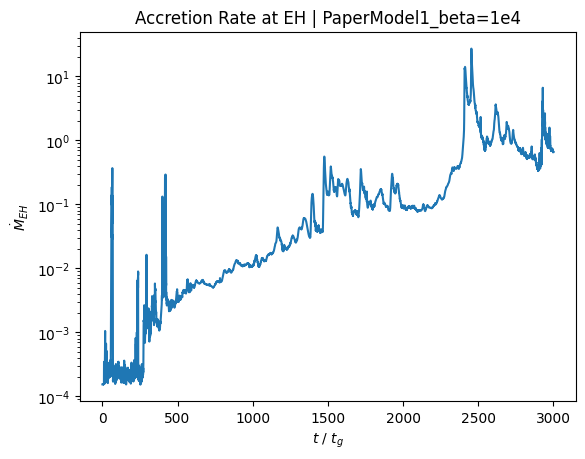

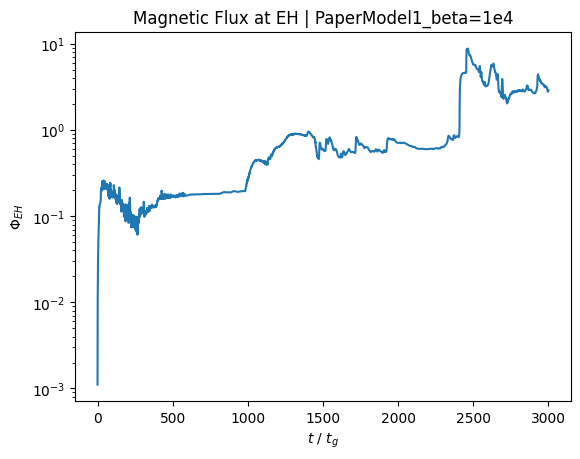

In [9]:
run_label = run_meta_resolved["display"]

plt.plot(df["time"], df["Mdot_EH"])
plt.xlabel(r"$t$ / $t_g$")
plt.ylabel(r"$\dot M_{EH}$")
plt.yscale("log")
plt.title(f"Accretion Rate at EH | {run_label}")
plt.show()

plt.plot(df["time"], df["Phi_EH"])
plt.xlabel(r"$t$ / $t_g$")
plt.ylabel(r"$\Phi_{EH}$")
plt.yscale("log")
plt.title(f"Magnetic Flux at EH | {run_label}")
plt.show()

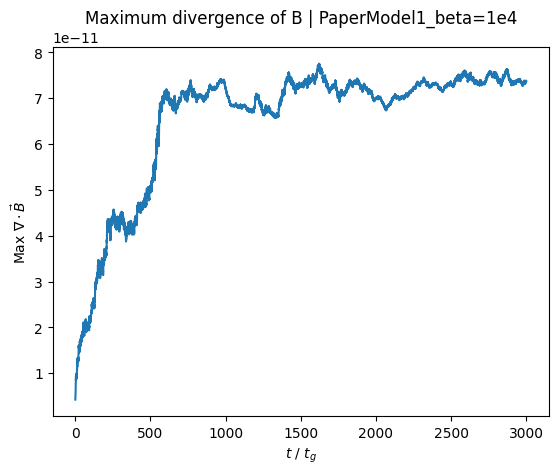

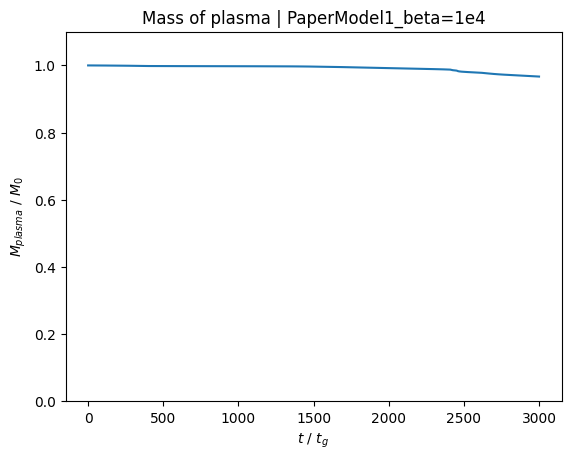

In [10]:
run_label = run_meta_resolved["display"]

plt.plot(df["time"], df["MaxDivB"])
plt.xlabel(r"$t$ / $t_g$")
plt.ylabel(r"Max $\nabla \cdot \vec B$")
# plt.yscale("log")
plt.title(f"Maximum divergence of B | {run_label}")
plt.show()

plt.plot(df["time"], df["Mass"]/df["Mass"][0])
plt.xlabel(r"$t$ / $t_g$")
plt.ylabel(r"$M_{plasma}$ / $M_0$")
# plt.yscale("log")
plt.ylim(0, 1.1)
plt.title(f"Mass of plasma | {run_label}")
plt.show()

## 2D plots

In [15]:
with h5py.File(dump_file, "r") as f:
    # shapes from your xdmf:
    # prims.rho: (nblock, 1, n2, n1), Locations/x: (nblock, n1+1), Locations/y: (nblock, n2+1)
    rho_blk = f["prims.rho"][:, 0, :, :]      # (nblock, n2, n1)
    x_edges_blk = f["Locations/x"][:]          # (nblock, n1+1)
    y_edges_blk = f["Locations/y"][:]          # (nblock, n2+1)

# Order blocks by their y start, then concatenate in y
order = np.argsort(y_edges_blk[:, 0])
rho = np.concatenate([rho_blk[b] for b in order], axis=0)  # (N2, N1)

x_edges = x_edges_blk[order[0]]
y_edges = np.concatenate(
    [y_edges_blk[b][:-1] for b in order] + [y_edges_blk[order[-1]][-1:]]
)

print("rho shape:", rho.shape)
print("x_edges:", x_edges.shape, "y_edges:", y_edges.shape)

rho shape: (256, 83)
x_edges: (84,) y_edges: (257,)


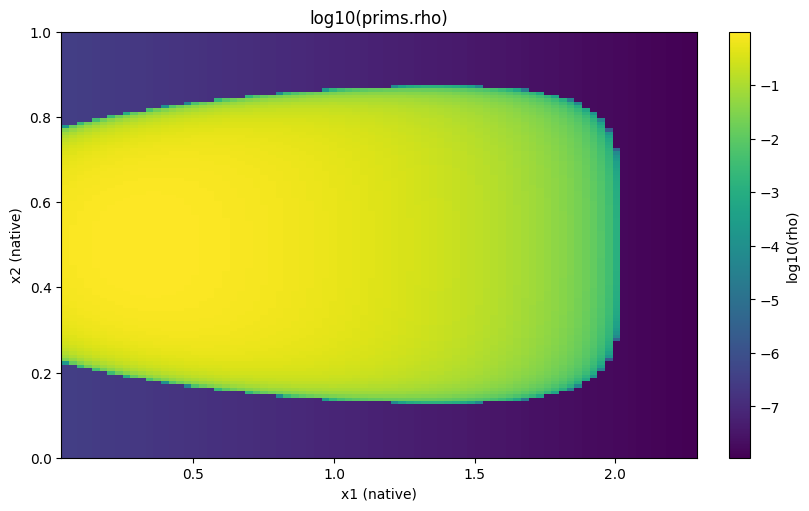

In [16]:
X, Y = np.meshgrid(x_edges, y_edges)
rho_log = np.log10(np.maximum(rho, 1e-30))

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
im = ax.pcolormesh(X, Y, rho_log, shading="auto", cmap="viridis")
ax.set_xlabel("x1 (native)")
ax.set_ylabel("x2 (native)")
ax.set_title("log10(prims.rho)")
plt.colorbar(im, ax=ax, label="log10(rho)")
plt.show()

In [ ]:
def plot_primitives_rz(
    dump_file=None,
    output_index=None,
    available_dumps=None,
    variables=("rho",),
    var_labels=None,
    log_scale=True,
    log_floor=1e-30,
    cmaps=("viridis", "plasma"),
    vmin=None,
    vmax=None,
    add_magnetic_contours=True,
    contour_levels=20,
    contour_color="mediumvioletred",
    contour_alpha=0.9,
    phi_index=0,
    show_horizon=True,
    figsize=(14, 9),
    axis_limit=None,
    gamma=4.0/3.0,
):
    """Plot KHARMA primitive variables in cylindrical (r_cyl, z) coordinates."""
    if isinstance(variables, str):
        variables = [variables]
    else:
        variables = list(variables)

    glue_hemispheres = len(variables) == 2
    if len(variables) < 1 or len(variables) > 2:
        raise ValueError("Pass one or two variable names in 'variables'.")

    if isinstance(cmaps, str):
        cmaps = [cmaps]
    else:
        cmaps = list(cmaps)
    if len(cmaps) < len(variables):
        cmaps += [cmaps[-1]] * (len(variables) - len(cmaps))

    def _expand_arg(arg, n):
        if isinstance(arg, (list, tuple, np.ndarray)):
            if len(arg) != n:
                raise ValueError(f"Expected {n} entries, got {len(arg)}")
            return list(arg)
        return [arg] * n

    log_flags = _expand_arg(log_scale, len(variables))
    vmins = _expand_arg(vmin, len(variables))
    vmaxs = _expand_arg(vmax, len(variables))

    dump_path, resolved_index, n_outputs = _resolve_dump_path(
        dump_file=dump_file,
        output_index=output_index,
        available_dumps=available_dumps,
    )
    dump_time = _read_dump_time(dump_path)
    par_files = sorted(dump_path.parent.glob("*.par"))
    par_cfg = _read_par_file(par_files[0]) if par_files else {}
    # Adiabatic index from the run deck (GRMHD/gamma), not hardcoded 4/3.
    gamma = float(par_cfg.get("GRMHD/gamma", gamma))

    with h5py.File(dump_path, "r") as fh:
        x_edges_blk = fh["Locations/x"][:]
        y_edges_blk = fh["Locations/y"][:]

        if "VolumeLocations/x" in fh:
            x_centers_blk = fh["VolumeLocations/x"][:]
        else:
            x_centers_blk = 0.5 * (x_edges_blk[:, :-1] + x_edges_blk[:, 1:])

        if "VolumeLocations/y" in fh:
            y_centers_blk = fh["VolumeLocations/y"][:]
        else:
            y_centers_blk = 0.5 * (y_edges_blk[:, :-1] + y_edges_blk[:, 1:])

        block_ids = _build_block_grid(x_edges_blk, y_edges_blk)
        x_block_ids = block_ids[0, :]
        y_block_ids = block_ids[:, 0]

        x_edges = np.concatenate(
            [x_edges_blk[b][:-1] for b in x_block_ids] + [x_edges_blk[x_block_ids[-1]][-1:]]
        )
        x_centers = np.concatenate([x_centers_blk[b] for b in x_block_ids])
        y_edges = np.concatenate(
            [y_edges_blk[b][:-1] for b in y_block_ids] + [y_edges_blk[y_block_ids[-1]][-1:]]
        )
        y_centers = np.concatenate([y_centers_blk[b] for b in y_block_ids])

        derived_vars = {var for var in variables if _resolve_primitive(var)[0] == "derived"}

        rho, u, u1, u2, u3, B1, B2, B3 = None, None, None, None, None, None, None, None
        gcov = None
        gcon = None
        if derived_vars:
            rho_arr_blk = _load_primitive_2d(fh, "prims.rho", component=None, phi_index=phi_index)
            rho = _stitch_blocks_2d(rho_arr_blk, block_ids)

            u_arr_blk = _load_primitive_2d(fh, "prims.u", component=None, phi_index=phi_index)
            u = _stitch_blocks_2d(u_arr_blk, block_ids)

            u1_arr_blk = _load_primitive_2d(fh, "prims.uvec", component=0, phi_index=phi_index)
            u1 = _stitch_blocks_2d(u1_arr_blk, block_ids)

            u2_arr_blk = _load_primitive_2d(fh, "prims.uvec", component=1, phi_index=phi_index)
            u2 = _stitch_blocks_2d(u2_arr_blk, block_ids)

            u3_arr_blk = _load_primitive_2d(fh, "prims.uvec", component=2, phi_index=phi_index)
            u3 = _stitch_blocks_2d(u3_arr_blk, block_ids)

            B1_arr_blk = _load_primitive_2d(fh, "prims.B", component=0, phi_index=phi_index)
            B1 = _stitch_blocks_2d(B1_arr_blk, block_ids)

            B2_arr_blk = _load_primitive_2d(fh, "prims.B", component=1, phi_index=phi_index)
            B2 = _stitch_blocks_2d(B2_arr_blk, block_ids)

            B3_arr_blk = _load_primitive_2d(fh, "prims.B", component=2, phi_index=phi_index)
            B3 = _stitch_blocks_2d(B3_arr_blk, block_ids)

            # Metric lives in the geometry (out3) dump, not the primitive (out0) dump.
            gcov, gcon = _load_metric_components_2d(dump_path, block_ids, phi_index=phi_index)

        fields = []
        default_labels = []
        for var in variables:
            ds_name, comp, label = _resolve_primitive(var)
            if ds_name == "derived":
                fields.append(None)
                default_labels.append(label)
            else:
                arr_blk = _load_primitive_2d(fh, ds_name, component=comp, phi_index=phi_index)
                arr = _stitch_blocks_2d(arr_blk, block_ids)
                fields.append(arr)
                default_labels.append(label)

        if derived_vars:
            beta, sigma_rho, sigma_w, _ = _compute_beta_sigma(
                rho, u, B1, B2, B3, gamma=gamma,
                u1=u1, u2=u2, u3=u3, gcov=gcov, gcon=gcon,
            )
            derived_arrays = {"beta": beta, "sigma_rho": sigma_rho, "sigma_w": sigma_w}
            for i, var in enumerate(variables):
                if var.lower() in derived_arrays:
                    fields[i] = derived_arrays[var.lower()]

        B1_blk = None
        if add_magnetic_contours:
            b_ds, b_comp, _ = _resolve_primitive("B1")
            B1_blk = _load_primitive_2d(fh, b_ds, component=b_comp, phi_index=phi_index)
            B1_blk = _stitch_blocks_2d(B1_blk, block_ids)

    labels = default_labels if var_labels is None else list(var_labels)
    if len(labels) != len(variables):
        raise ValueError("Length of var_labels must match number of variables.")

    coord_cfg = {
        "transform": str(par_cfg.get("coordinates/transform", "mks")).lower(),
        "hslope": float(par_cfg.get("coordinates/hslope", 0.3)),
        "mks_smooth": float(par_cfg.get("coordinates/mks_smooth", 0.5)),
        "poly_xt": float(par_cfg.get("coordinates/poly_xt", 0.82)),
        "poly_alpha": float(par_cfg.get("coordinates/poly_alpha", 14.0)),
        "startx1": float(
            par_cfg.get(
                "coordinates/fmks_zero_point",
                par_cfg.get("parthenon/mesh/x1min", float(x_edges[0])),
            )
        ),
        "a": float(par_cfg.get("coordinates/a", 0.0)),
    }

    X1e, X2e = np.meshgrid(x_edges, y_edges)
    X1c, X2c = np.meshgrid(x_centers, y_centers)
    r_edges, th_edges = _native_to_r_theta(X1e, X2e, coord_cfg)
    r_cent, th_cent = _native_to_r_theta(X1c, X2c, coord_cfg)

    flux = None
    contour_vals = None
    if add_magnetic_contours and B1_blk is not None:
        flux = _metric_flux_from_b1(
            B1_blk,
            y_centers,
            dump_path,
            block_ids=block_ids,
            phi_index=phi_index,
            warn_on_fallback=True,
        )
        qlo, qhi = [float(v) for v in np.nanquantile(flux, [0.1, 0.9])]
        if not np.isfinite(qlo) or not np.isfinite(qhi) or np.isclose(qlo, qhi):
            qlo, qhi = float(np.nanmin(flux)), float(np.nanmax(flux))
        if np.isfinite(qlo) and np.isfinite(qhi):
            qlo, qhi = max(min(qlo, qhi), 1e-5), max(qlo, qhi, 1e-5)
            if not np.isclose(qlo, qhi):
                contour_vals = np.linspace(qlo, qhi, int(contour_levels))

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    exs = [0.0]
    if len(variables) == 2:
        exs = [0.0, np.pi] if glue_hemispheres else [0.0, 0.0]

    ims = []
    plotted_labels = []
    for i, field in enumerate(fields):
        show_data = np.array(field, copy=True)
        cb_label = labels[i]

        if log_flags[i]:
            show_data = np.log10(np.maximum(show_data, log_floor))
            cb_label = rf"$\log_{{10}}$({cb_label})"

        ex = exs[i]
        r_cyl_edges = r_edges * np.sin(th_edges + ex)
        z_edges = r_edges * np.cos(th_edges + ex) * np.cos(ex)

        im = ax.pcolormesh(
            r_cyl_edges,
            z_edges,
            show_data,
            shading="auto",
            cmap=cmaps[i],
            vmin=vmins[i],
            vmax=vmaxs[i],
        )
        ims.append(im)
        plotted_labels.append(cb_label)

        if contour_vals is not None:
            r_cyl_cent = r_cent * np.sin(th_cent + ex)
            z_cent = r_cent * np.cos(th_cent + ex) * np.cos(ex)
            ax.contour(
                r_cyl_cent,
                z_cent,
                flux,
                levels=contour_vals,
                colors=contour_color,
                linewidths=1.0,
                alpha=contour_alpha,
            )

    if len(ims) == 1:
        plt.colorbar(ims[0], ax=ax, label=plotted_labels[0], location="right")
    else:
        plt.colorbar(ims[0], ax=ax, label=plotted_labels[0], location="right", pad=0.08)
        plt.colorbar(ims[1], ax=ax, label=plotted_labels[1], location="left", pad=0.08)

    if show_horizon:
        a_spin = coord_cfg["a"]
        r_h = 1.0 + np.sqrt(max(0.0, 1.0 - a_spin * a_spin))
        ax.add_patch(plt.Circle((0.0, 0.0), r_h, color="black", zorder=5))

    title_vars = run_label
    if resolved_index is not None and n_outputs is not None:
        title_vars += f" | output[{resolved_index}]/{n_outputs - 1}"
    if dump_time is not None:
        title_vars += f" | t = {dump_time:.3f}"

    ax.set_xlabel(r"$r$ $/$ $r_g$")
    ax.set_ylabel(r"$z$ $/$ $r_g$")
    ax.set_title(title_vars)
    ax.set_aspect("equal")
    axis_bounds = _normalize_axis_limit(axis_limit)
    if axis_bounds is not None:
        xlim, ylim = axis_bounds
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.25)
    plt.show()
    return fig, ax

In [ ]:
def _resolve_dump_sequence(dump_file=None, available_dumps=None, start_index=None, stop_index=None, step=1):
    if step == 0:
        raise ValueError("step must be non-zero.")

    if available_dumps is None:
        if "dump_files" in globals() and len(globals()["dump_files"]) > 0:
            available_dumps = globals()["dump_files"]
        elif dump_file is not None:
            inferred = sorted(Path(dump_file).parent.glob("torus.out0.*.phdf"))
            available_dumps = inferred if inferred else [Path(dump_file)]
        else:
            available_dumps = []

    all_dumps = sorted(Path(path) for path in available_dumps)
    numbered = []
    for path in all_dumps:
        match = re.search(r"\.out0\.(\d+)\.phdf$", path.name)
        if match:
            numbered.append((int(match.group(1)), path))
    if numbered:
        all_dumps = [path for _, path in sorted(numbered, key=lambda item: item[0])]
    if not all_dumps:
        raise FileNotFoundError("No dump files available for movie generation.")

    selected_dumps = all_dumps[slice(start_index, stop_index, step)]
    if not selected_dumps:
        raise ValueError("Selected dump range produced no frames.")

    index_lookup = {path: idx for idx, path in enumerate(all_dumps)}
    selected_indices = [index_lookup[path] for path in selected_dumps]
    return selected_dumps, selected_indices, all_dumps


def make_primitives_rz_movie(
    output_file="primitives_rz_movie.mp4",
    dump_file=None,
    available_dumps=None,
    start_index=None,
    stop_index=None,
    step=1,
    variables=("rho",),
    var_labels=None,
    log_scale=True,
    log_floor=1e-30,
    cmaps=("viridis", "plasma"),
    vmin=None,
    vmax=None,
    add_magnetic_contours=True,
    contour_levels=20,
    contour_color="mediumvioletred",
    contour_alpha=0.9,
    phi_index=0,
    show_horizon=True,
    figsize=(12, 8),
    axis_limit=None,
    fps=10,
    dpi=120,
    bitrate=1800,
    overwrite=False,
    verbose=True,
    gamma=4.0/3.0,
):
    """
    Make an MP4 movie using the same cylindrical r-z plotting style as plot_primitives_rz.


    By default, this writes all available outputs to an MP4 in the run directory.
    Use start_index, stop_index, and step to make shorter previews or subsampled movies.

    Parameters
    ----------
    gamma : float, optional
        Adiabatic index for derived variables (beta, sigma_rho, sigma_w). Default: 4/3.
        Overridden by GRMHD/gamma in the run's .par file when present.
    """
    if not writers.is_available("ffmpeg"):
        raise RuntimeError("ffmpeg is not available to Matplotlib, so MP4 export cannot run.")

    if isinstance(variables, str):
        variables = [variables]
    else:
        variables = list(variables)

    glue_hemispheres = len(variables) == 2

    if len(variables) < 1 or len(variables) > 2:
        raise ValueError("Pass one or two variable names in 'variables'.")

    if isinstance(cmaps, str):
        cmaps = [cmaps]
    else:
        cmaps = list(cmaps)
    if len(cmaps) < len(variables):
        cmaps += [cmaps[-1]] * (len(variables) - len(cmaps))

    def _expand_arg(arg, n):
        if isinstance(arg, (list, tuple, np.ndarray)):
            if len(arg) != n:
                raise ValueError(f"Expected {n} entries, got {len(arg)}")
            return list(arg)
        return [arg] * n

    log_flags = _expand_arg(log_scale, len(variables))
    vmins = _expand_arg(vmin, len(variables))
    vmaxs = _expand_arg(vmax, len(variables))

    labels = list(variables) if var_labels is None else list(var_labels)
    if len(labels) != len(variables):
        raise ValueError("Length of var_labels must match number of variables.")

    selected_dumps, selected_indices, all_dumps = _resolve_dump_sequence(
        dump_file=dump_file,
        available_dumps=available_dumps,
        start_index=start_index,
        stop_index=stop_index,
        step=step,
    )

    output_path = Path(output_file)
    if not output_path.is_absolute():
        dump_parent = selected_dumps[0].parent.resolve()
        runs_root = next((p for p in [dump_parent] + list(dump_parent.parents) if p.name == "runs"), dump_parent)
        output_path = runs_root / output_path
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and not overwrite:
        raise FileExistsError(
            f"Output movie already exists: {output_path}. Pass overwrite=True to replace it."
        )

    par_files = sorted(selected_dumps[0].parent.glob("*.par"))
    par_cfg = _read_par_file(par_files[0]) if par_files else {}
    # Adiabatic index from the run deck (GRMHD/gamma), not hardcoded 4/3.
    gamma = float(par_cfg.get("GRMHD/gamma", gamma))

    derived_vars = {var for var in variables if _resolve_primitive(var)[0] == "derived"}

    need_scanned_limits = [vmins[i] is None or vmaxs[i] is None for i in range(len(variables))]
    if any(need_scanned_limits):
        scanned_mins = [np.inf] * len(variables)
        scanned_maxs = [-np.inf] * len(variables)
        if verbose:
            print(f"Scanning {len(selected_dumps)} frames for color limits...")

        for dump_path in selected_dumps:
            with h5py.File(dump_path, "r") as fh:
                x_edges_blk = fh["Locations/x"][:]
                y_edges_blk = fh["Locations/y"][:]
                block_ids = _build_block_grid(x_edges_blk, y_edges_blk)

                if derived_vars:
                    rho_arr_blk = _load_primitive_2d(fh, "prims.rho", component=None, phi_index=phi_index)
                    rho = _stitch_blocks_2d(rho_arr_blk, block_ids)

                    u_arr_blk = _load_primitive_2d(fh, "prims.u", component=None, phi_index=phi_index)
                    u = _stitch_blocks_2d(u_arr_blk, block_ids)

                    u1_arr_blk = _load_primitive_2d(fh, "prims.uvec", component=0, phi_index=phi_index)
                    u1 = _stitch_blocks_2d(u1_arr_blk, block_ids)
                    u2_arr_blk = _load_primitive_2d(fh, "prims.uvec", component=1, phi_index=phi_index)
                    u2 = _stitch_blocks_2d(u2_arr_blk, block_ids)
                    u3_arr_blk = _load_primitive_2d(fh, "prims.uvec", component=2, phi_index=phi_index)
                    u3 = _stitch_blocks_2d(u3_arr_blk, block_ids)

                    B1_arr_blk = _load_primitive_2d(fh, "prims.B", component=0, phi_index=phi_index)
                    B1 = _stitch_blocks_2d(B1_arr_blk, block_ids)

                    B2_arr_blk = _load_primitive_2d(fh, "prims.B", component=1, phi_index=phi_index)
                    B2 = _stitch_blocks_2d(B2_arr_blk, block_ids)

                    B3_arr_blk = _load_primitive_2d(fh, "prims.B", component=2, phi_index=phi_index)
                    B3 = _stitch_blocks_2d(B3_arr_blk, block_ids)

                    gcov, gcon = _load_metric_components_2d(dump_path, block_ids, phi_index=phi_index)

                    beta, sigma_rho, sigma_w, _ = _compute_beta_sigma(
                        rho, u, B1, B2, B3, gamma=gamma,
                        u1=u1, u2=u2, u3=u3, gcov=gcov, gcon=gcon,
                    )
                    derived_arrays = {
                        "beta": beta,
                        "sigma_rho": sigma_rho,
                        "sigma_w": sigma_w,
                    }

                for i_var, var in enumerate(variables):
                    if not need_scanned_limits[i_var]:
                        continue
                    ds_name, comp, _ = _resolve_primitive(var)

                    if ds_name == "derived":
                        arr = derived_arrays[var.lower()]
                    else:
                        arr_blk = _load_primitive_2d(fh, ds_name, component=comp, phi_index=phi_index)
                        arr = _stitch_blocks_2d(arr_blk, block_ids)

                    if log_flags[i_var]:
                        arr = np.log10(np.maximum(arr, log_floor))

                    local_min = float(np.nanmin(arr))
                    local_max = float(np.nanmax(arr))
                    if np.isfinite(local_min):
                        scanned_mins[i_var] = min(scanned_mins[i_var], local_min)
                    if np.isfinite(local_max):
                        scanned_maxs[i_var] = max(scanned_maxs[i_var], local_max)

        for i_var in range(len(variables)):
            if vmins[i_var] is None and np.isfinite(scanned_mins[i_var]):
                vmins[i_var] = scanned_mins[i_var]
            if vmaxs[i_var] is None and np.isfinite(scanned_maxs[i_var]):
                vmaxs[i_var] = scanned_maxs[i_var]

    base_coord_cfg = {
        "transform": str(par_cfg.get("coordinates/transform", "mks")).lower(),
        "hslope": float(par_cfg.get("coordinates/hslope", 0.3)),
        "mks_smooth": float(par_cfg.get("coordinates/mks_smooth", 0.5)),
        "poly_xt": float(par_cfg.get("coordinates/poly_xt", 0.82)),
        "poly_alpha": float(par_cfg.get("coordinates/poly_alpha", 14.0)),
        "a": float(par_cfg.get("coordinates/a", 0.0)),
    }

    fig = plt.figure(figsize=figsize, constrained_layout=False)
    writer = FFMpegWriter(
        fps=fps,
        metadata={"artist": "GitHub Copilot", "title": output_path.name},
        bitrate=bitrate,
    )

    if verbose:
        print(f"Writing {len(selected_dumps)} frames to {output_path}...")

    with writer.saving(fig, str(output_path), dpi=dpi):
        for frame_number, (dump_path, resolved_index) in enumerate(
            zip(selected_dumps, selected_indices), start=1
        ):
            dump_time = _read_dump_time(dump_path)

            with h5py.File(dump_path, "r") as fh:
                x_edges_blk = fh["Locations/x"][:]
                y_edges_blk = fh["Locations/y"][:]

                if "VolumeLocations/x" in fh:
                    x_centers_blk = fh["VolumeLocations/x"][:]
                else:
                    x_centers_blk = 0.5 * (x_edges_blk[:, :-1] + x_edges_blk[:, 1:])

                if "VolumeLocations/y" in fh:
                    y_centers_blk = fh["VolumeLocations/y"][:]
                else:
                    y_centers_blk = 0.5 * (y_edges_blk[:, :-1] + y_edges_blk[:, 1:])

                block_ids = _build_block_grid(x_edges_blk, y_edges_blk)
                x_block_ids = block_ids[0, :]
                y_block_ids = block_ids[:, 0]
                x_edges = np.concatenate(
                    [x_edges_blk[b][:-1] for b in x_block_ids] + [x_edges_blk[x_block_ids[-1]][-1:]]
                )
                x_centers = np.concatenate([x_centers_blk[b] for b in x_block_ids])
                y_edges = np.concatenate(
                    [y_edges_blk[b][:-1] for b in y_block_ids] + [y_edges_blk[y_block_ids[-1]][-1:]]
                )
                y_centers = np.concatenate([y_centers_blk[b] for b in y_block_ids])

                if derived_vars:
                    rho_arr_blk = _load_primitive_2d(fh, "prims.rho", component=None, phi_index=phi_index)
                    rho = _stitch_blocks_2d(rho_arr_blk, block_ids)

                    u_arr_blk = _load_primitive_2d(fh, "prims.u", component=None, phi_index=phi_index)
                    u = _stitch_blocks_2d(u_arr_blk, block_ids)

                    u1_arr_blk = _load_primitive_2d(fh, "prims.uvec", component=0, phi_index=phi_index)
                    u1 = _stitch_blocks_2d(u1_arr_blk, block_ids)
                    u2_arr_blk = _load_primitive_2d(fh, "prims.uvec", component=1, phi_index=phi_index)
                    u2 = _stitch_blocks_2d(u2_arr_blk, block_ids)
                    u3_arr_blk = _load_primitive_2d(fh, "prims.uvec", component=2, phi_index=phi_index)
                    u3 = _stitch_blocks_2d(u3_arr_blk, block_ids)

                    B1_arr_blk = _load_primitive_2d(fh, "prims.B", component=0, phi_index=phi_index)
                    B1 = _stitch_blocks_2d(B1_arr_blk, block_ids)

                    B2_arr_blk = _load_primitive_2d(fh, "prims.B", component=1, phi_index=phi_index)
                    B2 = _stitch_blocks_2d(B2_arr_blk, block_ids)

                    B3_arr_blk = _load_primitive_2d(fh, "prims.B", component=2, phi_index=phi_index)
                    B3 = _stitch_blocks_2d(B3_arr_blk, block_ids)

                    gcov, gcon = _load_metric_components_2d(dump_path, block_ids, phi_index=phi_index)

                    beta, sigma_rho, sigma_w, _ = _compute_beta_sigma(
                        rho, u, B1, B2, B3, gamma=gamma,
                        u1=u1, u2=u2, u3=u3, gcov=gcov, gcon=gcon,
                    )
                    derived_arrays = {
                        "beta": beta,
                        "sigma_rho": sigma_rho,
                        "sigma_w": sigma_w,
                    }

                fields = []
                for var in variables:
                    ds_name, comp, _ = _resolve_primitive(var)

                    if ds_name == "derived":
                        fields.append(derived_arrays[var.lower()])
                    else:
                        arr_blk = _load_primitive_2d(fh, ds_name, component=comp, phi_index=phi_index)
                        fields.append(_stitch_blocks_2d(arr_blk, block_ids))

                B1_blk = None
                if add_magnetic_contours:
                    b_ds, b_comp, _ = _resolve_primitive("B1")
                    B_arr_blk = _load_primitive_2d(fh, b_ds, component=b_comp, phi_index=phi_index)
                    B1_blk = _stitch_blocks_2d(B_arr_blk, block_ids)

            coord_cfg = dict(base_coord_cfg)
            coord_cfg["startx1"] = float(
                par_cfg.get(
                    "coordinates/fmks_zero_point",
                    par_cfg.get("parthenon/mesh/x1min", float(x_edges[0])),
                )
            )

            X1e, X2e = np.meshgrid(x_edges, y_edges)
            X1c, X2c = np.meshgrid(x_centers, y_centers)
            r_edges, th_edges = _native_to_r_theta(X1e, X2e, coord_cfg)
            r_cent, th_cent = _native_to_r_theta(X1c, X2c, coord_cfg)

            flux = None
            contour_vals = None
            if add_magnetic_contours and B1_blk is not None:
                flux = _metric_flux_from_b1(
                    B1_blk,
                    y_centers,
                    dump_path,
                    block_ids=block_ids,
                    phi_index=phi_index,
                    warn_on_fallback=(verbose and frame_number == 1),
                )
                qlo, qhi = [float(v) for v in np.nanquantile(flux, [0.1, 0.9])]
                if not np.isfinite(qlo) or not np.isfinite(qhi) or np.isclose(qlo, qhi):
                    qlo, qhi = float(np.nanmin(flux)), float(np.nanmax(flux))
                if np.isfinite(qlo) and np.isfinite(qhi):
                    qlo, qhi = max(min(qlo, qhi), 1e-5), max(qlo, qhi, 1e-5)
                    if not np.isclose(qlo, qhi):
                        contour_vals = np.linspace(qlo, qhi, int(contour_levels))

            fig.clear()
            ax = fig.add_subplot(111)
            if len(variables) == 2:
                fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.10)
            else:
                fig.subplots_adjust(left=0.10, right=0.90, top=0.93, bottom=0.10)

            exs = [0.0]
            if len(variables) == 2:
                exs = [0.0, np.pi] if glue_hemispheres else [0.0, 0.0]

            ims = []
            plotted_labels = []
            for i_var, field in enumerate(fields):
                show_data = np.array(field, copy=True)
                cb_label = labels[i_var]

                if log_flags[i_var]:
                    show_data = np.log10(np.maximum(show_data, log_floor))
                    cb_label = rf"$\log_{{10}}$({cb_label})"

                ex = exs[i_var]
                r_cyl_edges = r_edges * np.sin(th_edges + ex)
                z_edges = r_edges * np.cos(th_edges + ex) * np.cos(ex)

                im = ax.pcolormesh(
                    r_cyl_edges,
                    z_edges,
                    show_data,
                    shading="auto",
                    cmap=cmaps[i_var],
                    vmin=vmins[i_var],
                    vmax=vmaxs[i_var],
                )
                ims.append(im)
                plotted_labels.append(cb_label)

                if contour_vals is not None:
                    r_cyl_cent = r_cent * np.sin(th_cent + ex)
                    z_cent = r_cent * np.cos(th_cent + ex) * np.cos(ex)
                    ax.contour(
                        r_cyl_cent,
                        z_cent,
                        flux,
                        levels=contour_vals,
                        colors=contour_color,
                        linewidths=1.0,
                        alpha=contour_alpha,
                    )

            if len(ims) == 1:
                fig.colorbar(ims[0], ax=ax, label=plotted_labels[0], location="right")
            else:
                fig.colorbar(ims[0], ax=ax, label=plotted_labels[0], location="right", pad=0.08)
                cbar_left = fig.colorbar(ims[1], ax=ax, label=plotted_labels[1], location="left", pad=0.12)
                cbar_left.ax.yaxis.set_label_position("left")
                cbar_left.ax.yaxis.set_ticks_position("left")
                cbar_left.ax.tick_params(labelleft=True, labelright=False)

            if show_horizon:
                a_spin = coord_cfg["a"]
                r_h = 1.0 + np.sqrt(max(0.0, 1.0 - a_spin * a_spin))
                ax.add_patch(plt.Circle((0.0, 0.0), r_h, color="black", zorder=5))

            title_vars = f"{run_label}"
            title_vars += f" | output[{resolved_index}]/{len(all_dumps) - 1}"
            if dump_time is not None:
                title_vars += f" | t = {dump_time:.3f}"

            ax.set_xlabel(r"$r$ / $r_g$")
            ax.set_ylabel(r"$z$ / $r_g$")
            ax.set_title(title_vars)
            ax.set_aspect("equal")
            axis_bounds = _normalize_axis_limit(axis_limit)
            if axis_bounds is not None:
                xlim, ylim = axis_bounds
                ax.set_xlim(*xlim)
                ax.set_ylim(*ylim)
            ax.grid(alpha=0.25)

            writer.grab_frame()

            if verbose:
                print(
                    f"  rendered frame {frame_number}/{len(selected_dumps)}: {dump_path.name}",
                    end="\r",
                )

    plt.close(fig)

    if verbose:
        print()
        print(f"Saved movie to {output_path}")

    return output_path


# Auto-fallback: if a run folder has no .par file, reconstruct one from dump metadata.
def _materialize_par_from_dump_if_missing(dump_path, par_name=".autogen_from_dump.par"):
    dump_path = Path(dump_path)
    run_dir = dump_path.parent
    existing = sorted(run_dir.glob("*.par"))
    if existing:
        return existing[0]

    with h5py.File(dump_path, "r") as fh:
        input_group = fh.get("Input", None)
        if input_group is None:
            return None
        raw = input_group.attrs.get("File", "")

    if isinstance(raw, bytes):
        raw = raw.decode("utf-8", errors="ignore")
    raw = str(raw).strip()
    if not raw:
        return None

    par_path = run_dir / par_name
    par_path.write_text(raw + "\n", encoding="utf-8")
    return par_path


if "_plot_primitives_rz_original" not in globals() and "plot_primitives_rz" in globals():
    _plot_primitives_rz_original = plot_primitives_rz

    def plot_primitives_rz(*args, **kwargs):
        dump_file_arg = kwargs.get("dump_file", args[0] if len(args) > 0 else None)
        output_index_arg = kwargs.get("output_index", args[1] if len(args) > 1 else None)
        available_dumps_arg = kwargs.get("available_dumps", args[2] if len(args) > 2 else None)

        dump_path, _, _ = _resolve_dump_path(
            dump_file=dump_file_arg,
            output_index=output_index_arg,
            available_dumps=available_dumps_arg,
        )
        _materialize_par_from_dump_if_missing(dump_path)
        return _plot_primitives_rz_original(*args, **kwargs)


if "_make_primitives_rz_movie_original" not in globals() and "make_primitives_rz_movie" in globals():
    _make_primitives_rz_movie_original = make_primitives_rz_movie

    def make_primitives_rz_movie(*args, **kwargs):
        dump_file_arg = kwargs.get("dump_file", args[1] if len(args) > 1 else None)
        available_dumps_arg = kwargs.get("available_dumps", args[2] if len(args) > 2 else None)
        start_index_arg = kwargs.get("start_index", args[3] if len(args) > 3 else None)
        stop_index_arg = kwargs.get("stop_index", args[4] if len(args) > 4 else None)
        step_arg = kwargs.get("step", args[5] if len(args) > 5 else 1)

        selected_dumps, _, _ = _resolve_dump_sequence(
            dump_file=dump_file_arg,
            available_dumps=available_dumps_arg,
            start_index=start_index_arg,
            stop_index=stop_index_arg,
            step=step_arg,
        )
        _materialize_par_from_dump_if_missing(selected_dumps[0])
        return _make_primitives_rz_movie_original(*args, **kwargs)

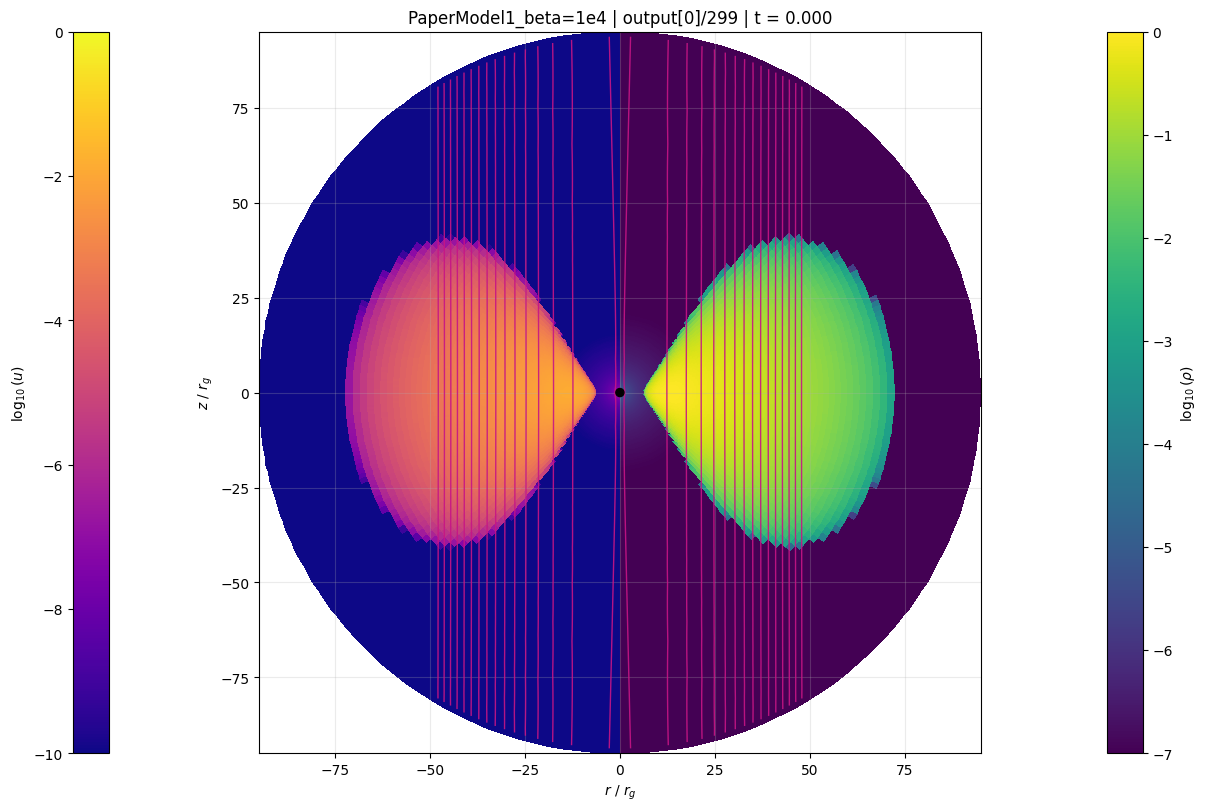

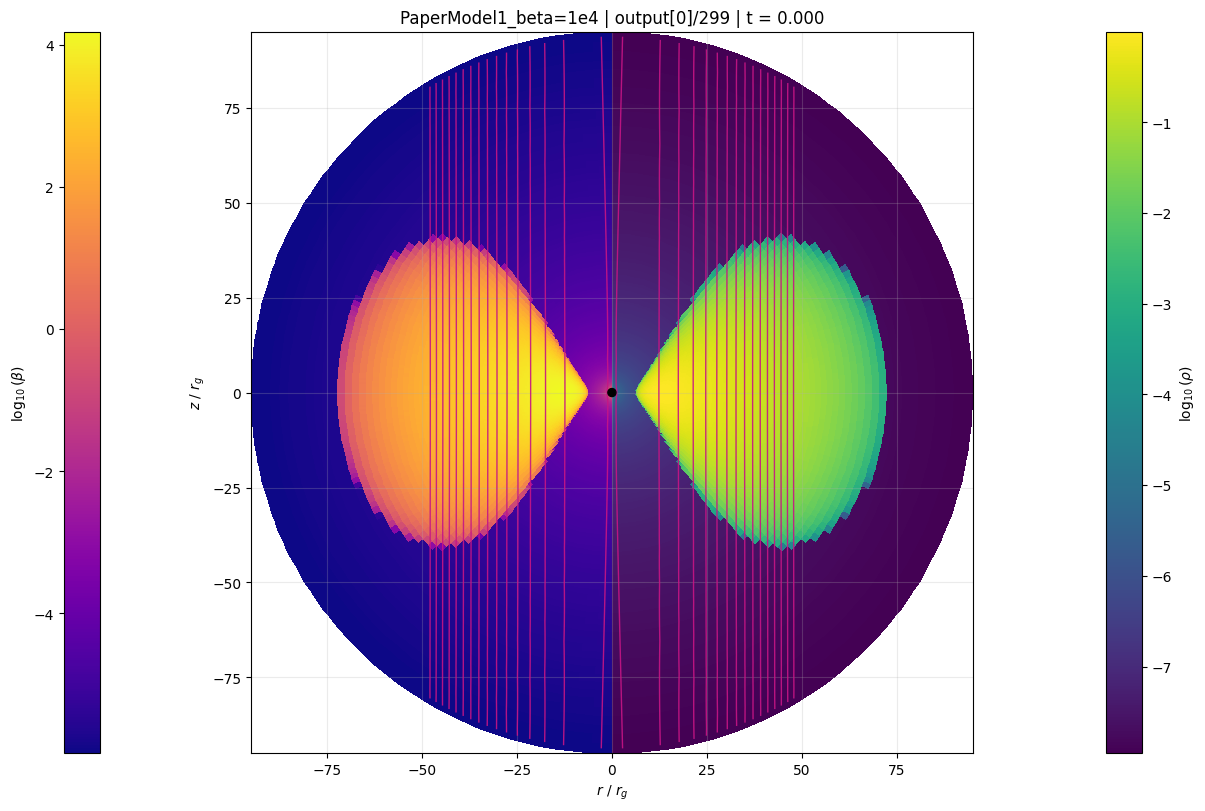

In [19]:
plot_primitives_rz(
    output_index=0,
    variables=("rho", "u"),
    var_labels=(r"$\rho$", r"$u$"),
    cmaps=("viridis", "plasma"),
    log_scale=(True, True),
    add_magnetic_contours=True,
    contour_levels=16,
    figsize=(12, 8),
    # vmin=[-7., -12.],
    vmin=[-7., -10.],
    vmax=[0., 0.],
    # axis_limit=(50, 50)
);

plot_primitives_rz(
    output_index=0,
    variables=("rho", "beta"),
    var_labels=(r"$\rho$", r"$\beta$"),
    cmaps=("viridis", "plasma"),
    log_scale=(True, True),
    add_magnetic_contours=True,
    contour_levels=16,
    figsize=(12, 8),
    # vmin=[-7., -12.],
    # vmin=[-7., -10.],
    # vmax=[0., 0.],
);


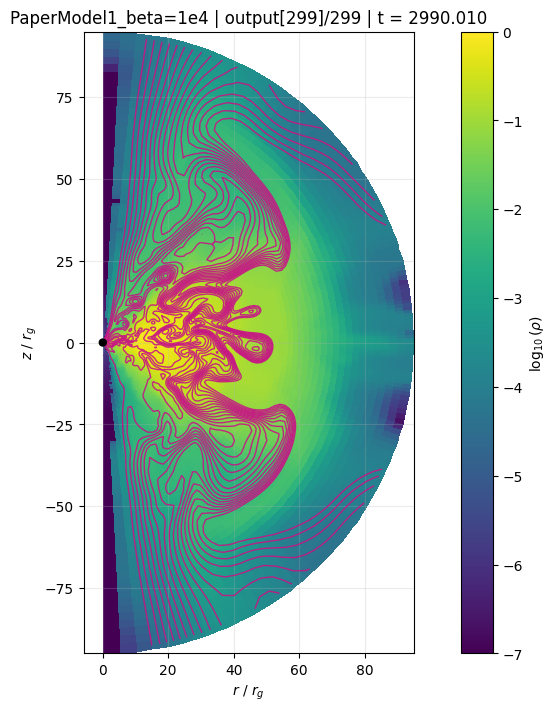

In [20]:
# Choose which output to plot via Python-style indexing:
# i = 0  -> first output (initial data)
# i = 3  -> fourth output
# i = -1 -> last output

i = -1
plot_primitives_rz(
    output_index=i,
    variables=("rho",),
    var_labels=(r"$\rho$",),
    cmaps=("viridis",),
    log_scale=True,
    add_magnetic_contours=True,
    contour_levels=16,
    figsize=(11, 7),
    vmin=[-7.,],
    vmax=[0.,],
);

## 2D movies

In [16]:
# Example movie calls:

# # Full movie using all outputs with rho
# make_primitives_rz_movie(
#     output_file="rhoWALD.mp4",
#     variables=("rho",),
#     var_labels=(r"$\rho$",),
#     fps=10,
#     vmin=[-7.,],
#     vmax=[0.,],
#     overwrite=True,
# )

# Two-variable movie
make_primitives_rz_movie(
    output_file=run_meta_resolved["movie_rsr"],
    variables=("rho", "sigma_rho"),
    var_labels=(r"$\rho$", r"$\sigma_{\rho}$"),
    fps=10,
    vmin=[-7., -8.],
    vmax=[0., 1.],
    overwrite=True,
)

# Two-variable movie
make_primitives_rz_movie(
    output_file=run_meta_resolved["movie_rb"],
    variables=("rho", "beta"),
    var_labels=(r"$\rho$", r"$\beta$"),
    fps=10,
    vmin=[-7., -2.],
    vmax=[0., 6.5],
    overwrite=True,
)

Writing 300 frames to /home/aaron/Research/kharma/runs/rho_sigma_rhoPAPER1_B0ss.mp4...
  rendered frame 300/300: torus.out0.00299.phdf
Saved movie to /home/aaron/Research/kharma/runs/rho_sigma_rhoPAPER1_B0ss.mp4
Writing 300 frames to /home/aaron/Research/kharma/runs/rho_betaPAPER1_B0ss.mp4...
  rendered frame 300/300: torus.out0.00299.phdf
Saved movie to /home/aaron/Research/kharma/runs/rho_betaPAPER1_B0ss.mp4


PosixPath('/home/aaron/Research/kharma/runs/rho_betaPAPER1_B0ss.mp4')

### Redo all movies

In [27]:
# Render `rho_sigma_rho` and `rho_beta` MP4s for EVERY run in `available_runs`
# (all paperModel*, sane, and wald runs). Outputs go into the `zvids/` folder,
# using the names already defined in `run_meta` (movie_rsr / movie_rb).

VIDEO_DIR = "zvids"   # subfolder of `runs/` that holds the MP4s
DRY_RUN = False       # set True to only print what WOULD be rendered
ONLY_RUNS = set()     # lower-case substrings to filter runs; empty -> all runs
AUTO_LIMITS = True    # True (default): each movie scans its OWN frames and uses
                      #   its own global vmin/vmax (per-run, per-movie).
                      # False: use the shared hardcoded limits below for all runs.

# Hard lower/upper bounds (log10). These are ALWAYS applied regardless of
# AUTO_LIMITS:
#   rho        colorbar: bottom 10^-7, top 10^0.5
#   sigma_rho colorbar: bottom 10^-8, top 10^5
#   beta       colorbar: bottom 10^-2, top 10^4.5
RHO_VMIN = -7.0        # rho colorbar bottom         = 10^-7
RHO_VMAX = 0.5         # rho colorbar top            = 10^0.5
SIGMA_RHO_VMIN = -8.0  # sigma_rho colorbar bottom   = 10^-8
SIGMA_RHO_VMAX = 5.0   # sigma_rho colorbar top      = 10^5
BETA_VMIN = -2.0       # beta colorbar bottom        = 10^-2
BETA_VMAX = 4.5        # beta colorbar top           = 10^4.5

# Shared color limits (log10 axes). Used ONLY when AUTO_LIMITS is False.
RSR_KW = dict(
    variables=("rho", "sigma_rho"),
    var_labels=(r"$\rho$", r"$\sigma_{\rho}$"),
    vmin=[RHO_VMIN, SIGMA_RHO_VMIN],
    vmax=[RHO_VMAX, SIGMA_RHO_VMAX],
)
RB_KW = dict(
    variables=("rho", "beta"),
    var_labels=(r"$\rho$", r"$\beta$"),
    vmin=[RHO_VMIN, BETA_VMIN],
    vmax=[RHO_VMAX, BETA_VMAX],
)
MOVIE_KW = dict(fps=10, overwrite=True, verbose=True)

# Snapshot the currently-selected run's globals so we can restore them afterward
# (the floor-mask movie cell below relies on dump_file/dump_files/run_meta_resolved).
_saved_globals = {
    k: globals().get(k)
    for k in ("run_dir", "dump_files", "dump_file", "run_meta_resolved", "run_label")
}

In [28]:
jobs = []   # (run_name, kind, output_path) — rendered or planned
for run_path, dumps in available_runs:
    name = run_path.name.lower()
    if ONLY_RUNS and not any(sub in name for sub in ONLY_RUNS):
        continue

    dumps_run = sorted(Path(p) for p in dumps)
    if not dumps_run:
        print(f"[skip] {run_path.name}: no dumps")
        continue

    matched = _match_run_meta(run_path.name)
    meta = run_meta.get(matched, {
        "display": run_path.name,
        "movie_rsr": f"{run_path.name}_rho_sigma_rho.mp4",
        "movie_rb": f"{run_path.name}_rho_beta.mp4",
    })

    # Point the title/metadata globals at this run.
    run_dir = str(run_path)
    dump_files = dumps_run
    dump_file = dumps_run[0]
    run_meta_resolved = meta
    run_label = meta.get("display", run_path.name)

    for kind, kw, out_name in (
        ("sigma_rho", RSR_KW, meta["movie_rsr"]),
        ("beta", RB_KW, meta["movie_rb"]),
    ):
        out = Path(VIDEO_DIR) / out_name
        jobs.append((run_path.name, kind, out))

        # Per-movie global limits. With AUTO_LIMITS on, pin the rho bounds
        # (10^-7..10^0.5) and the derived variable's bounds
        # (sigma_rho -> 10^-8..10^5, beta -> 10^-2..10^4.5). With AUTO_LIMITS
        # off, reuse the shared hardcoded limits from RSR_KW/RB_KW.
        kw = dict(kw)
        if AUTO_LIMITS:
            floor = SIGMA_RHO_VMIN if kind == "sigma_rho" else BETA_VMIN
            cap = SIGMA_RHO_VMAX if kind == "sigma_rho" else BETA_VMAX
            kw["vmin"] = [RHO_VMIN, floor]
            kw["vmax"] = [RHO_VMAX, cap]
            limits_note = f"fixed limits (rho {RHO_VMIN}..{RHO_VMAX}, var {floor}..{cap})"
        else:
            limits_note = f"fixed vmin={kw['vmin']} vmax={kw['vmax']}"

        if DRY_RUN:
            print(f"[dry-run] {run_path.name:45s} {kind:9s} -> {out}  ({limits_note})")
            continue
        print(f"=== {run_path.name} | {kind} -> {out}  ({limits_note}) ===")
        make_primitives_rz_movie(
            output_file=str(out),
            dump_file=dump_file,
            available_dumps=dump_files,
            **kw,
            **MOVIE_KW,
        )

# Restore the originally-selected run's globals for the cells that follow.
for k, v in _saved_globals.items():
    if v is not None:
        globals()[k] = v

print("\nFinished.")
verb = "Planned" if DRY_RUN else "Rendered"
print(f"{verb} {len(jobs)} movie(s) into {VIDEO_DIR}/:")
for run_name, kind, out in jobs:
    print(f"  {run_name:45s} {kind:9s} -> {out}")

=== paperModel1_a0.998_t2000_B0ss_20260331_204025 | sigma_rho -> zvids/rho_sigma_rhoPAPER1_B0ss.mp4  (fixed limits (rho -7.0..0.5, var -8.0..5.0)) ===
Writing 300 frames to /home/aaron/Research/kharma/runs/zvids/rho_sigma_rhoPAPER1_B0ss.mp4...
  rendered frame 300/300: torus.out0.00299.phdf
Saved movie to /home/aaron/Research/kharma/runs/zvids/rho_sigma_rhoPAPER1_B0ss.mp4
=== paperModel1_a0.998_t2000_B0ss_20260331_204025 | beta -> zvids/rho_betaPAPER1_B0ss.mp4  (fixed limits (rho -7.0..0.5, var -2.0..4.5)) ===
Writing 300 frames to /home/aaron/Research/kharma/runs/zvids/rho_betaPAPER1_B0ss.mp4...
  rendered frame 300/300: torus.out0.00299.phdf
Saved movie to /home/aaron/Research/kharma/runs/zvids/rho_betaPAPER1_B0ss.mp4
=== paperModel0_a0.998_t2000_B0ss_20260331_204025 | sigma_rho -> zvids/rho_sigma_rhoPAPER0_B0ss.mp4  (fixed limits (rho -7.0..0.5, var -8.0..5.0)) ===
Writing 300 frames to /home/aaron/Research/kharma/runs/zvids/rho_sigma_rhoPAPER0_B0ss.mp4...
  rendered frame 300/300: 

## Mask plots

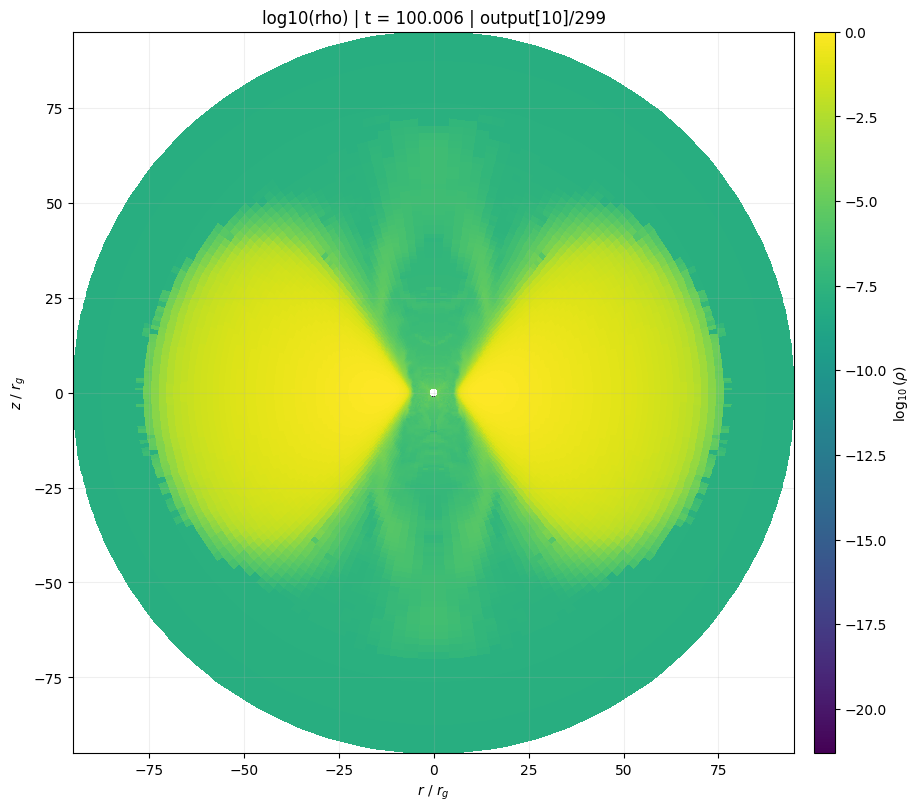

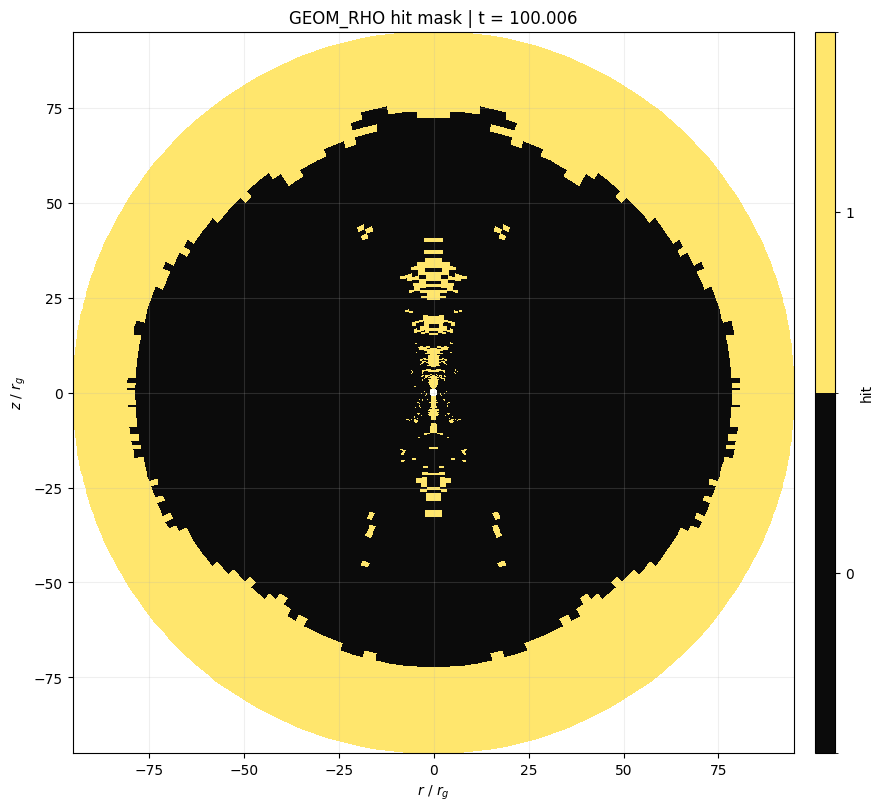

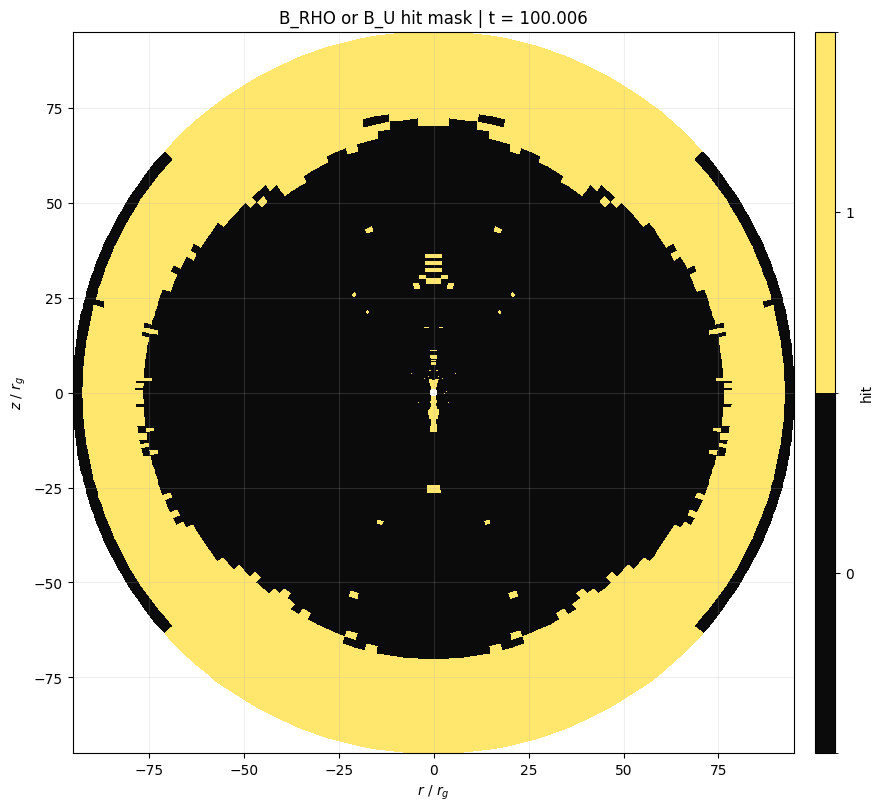

GEOM_RHO: 2159 cells
GEOM_U: 891 cells
B_RHO: 1469 cells
B_U: 676 cells
TEMP: 32 cells
GAMMA: 580 cells
KTOT: 0 cells
Any floor hit: 2372 cells


In [17]:
# Decode floor-hit masks for the selected frame.
frame_index = 10  # change as needed

# View controls:
# - Set r_limits/z_limits to None to show the full transformed grid.
# - Set tuples like (-40, 40) to zoom manually.
r_limits = None
z_limits = None
plot_in_physical_rz = True
plot_figsize = (11, 8)
cbar_kwargs = dict(fraction=0.04, pad=0.02, shrink=1.0, aspect=35)


def _apply_view_limits(ax, rlim=None, zlim=None):
    if rlim is not None:
        ax.set_xlim(float(rlim[0]), float(rlim[1]))
    if zlim is not None:
        ax.set_ylim(float(zlim[0]), float(zlim[1]))


# Resolve the dump for this output index using helpers defined above.
dump_path, resolved_index, n_outputs = _resolve_dump_path(output_index=frame_index)
dump_time = _read_dump_time(dump_path)

with h5py.File(dump_path, "r") as fh:
    x_edges_blk = fh["Locations/x"][:]
    y_edges_blk = fh["Locations/y"][:]
    block_ids = _build_block_grid(x_edges_blk, y_edges_blk)

    fflag_blk = fh["fflag"][:]
    if fflag_blk.ndim == 4:
        fflag_blk = fflag_blk[:, 0, :, :]
    elif fflag_blk.ndim == 3:
        pass
    else:
        raise ValueError(f"Unexpected fflag shape: {fflag_blk.shape}")

    fflag = _stitch_blocks_2d(fflag_blk, block_ids)
    fflag = np.asarray(fflag, dtype=np.int64)

    rho_blk = fh["prims.rho"][:, 0, :, :]
    rho = _stitch_blocks_2d(rho_blk, block_ids)

    x_centers_blk = fh["VolumeLocations/x"][:] if "VolumeLocations/x" in fh else 0.5 * (x_edges_blk[:, :-1] + x_edges_blk[:, 1:])
    y_centers_blk = fh["VolumeLocations/y"][:] if "VolumeLocations/y" in fh else 0.5 * (y_edges_blk[:, :-1] + y_edges_blk[:, 1:])
    x_block_ids = block_ids[0, :]
    y_block_ids = block_ids[:, 0]
    x_edges = np.concatenate([x_edges_blk[b][:-1] for b in x_block_ids] + [x_edges_blk[x_block_ids[-1]][-1:]])
    y_edges = np.concatenate([y_edges_blk[b][:-1] for b in y_block_ids] + [y_edges_blk[y_block_ids[-1]][-1:]])
    x_centers = np.concatenate([x_centers_blk[b] for b in x_block_ids])
    y_centers = np.concatenate([y_centers_blk[b] for b in y_block_ids])

Xe, Ye = np.meshgrid(x_edges, y_edges)

# Build plotting mesh in physical r-z so the full grid extent is visible.
if plot_in_physical_rz:
    par_files = sorted(dump_path.parent.glob("*.par"))
    par_cfg = _read_par_file(par_files[0]) if par_files else {}
    coord_cfg = {
        "transform": str(par_cfg.get("coordinates/transform", "mks")).lower(),
        "hslope": float(par_cfg.get("coordinates/hslope", 0.3)),
        "mks_smooth": float(par_cfg.get("coordinates/mks_smooth", 0.5)),
        "poly_xt": float(par_cfg.get("coordinates/poly_xt", 0.82)),
        "poly_alpha": float(par_cfg.get("coordinates/poly_alpha", 14.0)),
        "startx1": float(
            par_cfg.get(
                "coordinates/fmks_zero_point",
                par_cfg.get("parthenon/mesh/x1min", float(x_edges[0])),
            )
        ),
    }

    X1e, X2e = np.meshgrid(x_edges, y_edges)
    r_edges, th_edges = _native_to_r_theta(X1e, X2e, coord_cfg)

    Xplot = r_edges * np.sin(th_edges)
    Yplot = r_edges * np.cos(th_edges)
    Xplot_mirror = r_edges * np.sin(th_edges + np.pi)
    Yplot_mirror = r_edges * np.cos(th_edges + np.pi) * np.cos(np.pi)

    r_auto = float(np.nanmax(np.abs(Xplot)))
    z_auto = float(np.nanmax(np.abs(Yplot)))
    if not np.isfinite(r_auto) or r_auto <= 0:
        r_auto = 1.0
    if not np.isfinite(z_auto) or z_auto <= 0:
        z_auto = 1.0

    r_view = r_limits if r_limits is not None else (-r_auto, r_auto)
    z_view = z_limits if z_limits is not None else (-z_auto, z_auto)
    x_label = r"$r$ / $r_g$"
    y_label = r"$z$ / $r_g$"
else:
    Xplot, Yplot = Xe, Ye
    Xplot_mirror, Yplot_mirror = None, None
    r_view = r_limits
    z_view = z_limits
    x_label = "x1 (native)"
    y_label = "x2 (native)"

# Bit definitions from kharma/floors/floors.hpp
mask_defs = {
    "GEOM_RHO": 32,
    "GEOM_U": 64,
    "B_RHO": 128,
    "B_U": 256,
    "TEMP": 512,
    "GAMMA": 1024,
    "KTOT": 2048,
}

masks = {name: (fflag & bit) != 0 for name, bit in mask_defs.items()}

binary_cmap = plt.matplotlib.colors.ListedColormap(["#0b0b0b", "#ffe66d"])
binary_norm = plt.matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5], binary_cmap.N)

title_suffix = f" | t = {dump_time:.3f}" if dump_time is not None else ""

# Plot log10(rho) separately.
fig, ax = plt.subplots(figsize=plot_figsize, constrained_layout=True)
rho_log = np.log10(np.maximum(rho, 1e-30))
im = ax.pcolormesh(Xplot, Yplot, rho_log, shading="auto", cmap="viridis")
if Xplot_mirror is not None:
    ax.pcolormesh(Xplot_mirror, Yplot_mirror, rho_log, shading="auto", cmap="viridis")
ax.set_title(f"log10(rho){title_suffix} | output[{resolved_index}]/{n_outputs - 1}")
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.set_box_aspect(1)
_apply_view_limits(ax, r_view, z_view)
ax.grid(alpha=0.2)
fig.colorbar(im, ax=ax, label=r"$\log_{10}(\rho)$", **cbar_kwargs)
plt.show()

# Plot density-floor hits separately.
fig, ax = plt.subplots(figsize=plot_figsize, constrained_layout=True)
im = ax.pcolormesh(Xplot, Yplot, masks["GEOM_RHO"].astype(int), shading="auto", cmap=binary_cmap, norm=binary_norm)
if Xplot_mirror is not None:
    ax.pcolormesh(Xplot_mirror, Yplot_mirror, masks["GEOM_RHO"].astype(int), shading="auto", cmap=binary_cmap, norm=binary_norm)
ax.set_title(f"GEOM_RHO hit mask{title_suffix}")
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.set_box_aspect(1)
_apply_view_limits(ax, r_view, z_view)
ax.grid(alpha=0.2)
fig.colorbar(im, ax=ax, ticks=[0, 1], label="hit", **cbar_kwargs)
plt.show()

# Plot magnetization-related hits separately.
fig, ax = plt.subplots(figsize=plot_figsize, constrained_layout=True)
mag_mask = masks["B_RHO"] | masks["B_U"]
im = ax.pcolormesh(Xplot, Yplot, mag_mask.astype(int), shading="auto", cmap=binary_cmap, norm=binary_norm)
if Xplot_mirror is not None:
    ax.pcolormesh(Xplot_mirror, Yplot_mirror, mag_mask.astype(int), shading="auto", cmap=binary_cmap, norm=binary_norm)
ax.set_title(f"B_RHO or B_U hit mask{title_suffix}")
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.set_box_aspect(1)
_apply_view_limits(ax, r_view, z_view)
ax.grid(alpha=0.2)
fig.colorbar(im, ax=ax, ticks=[0, 1], label="hit", **cbar_kwargs)
plt.show()

# Quick summary of which floor bits are active in this frame.
for name, bit in mask_defs.items():
    print(f"{name}: {int(np.count_nonzero(masks[name]))} cells")
print(f"Any floor hit: {int(np.count_nonzero(fflag > 0))} cells")

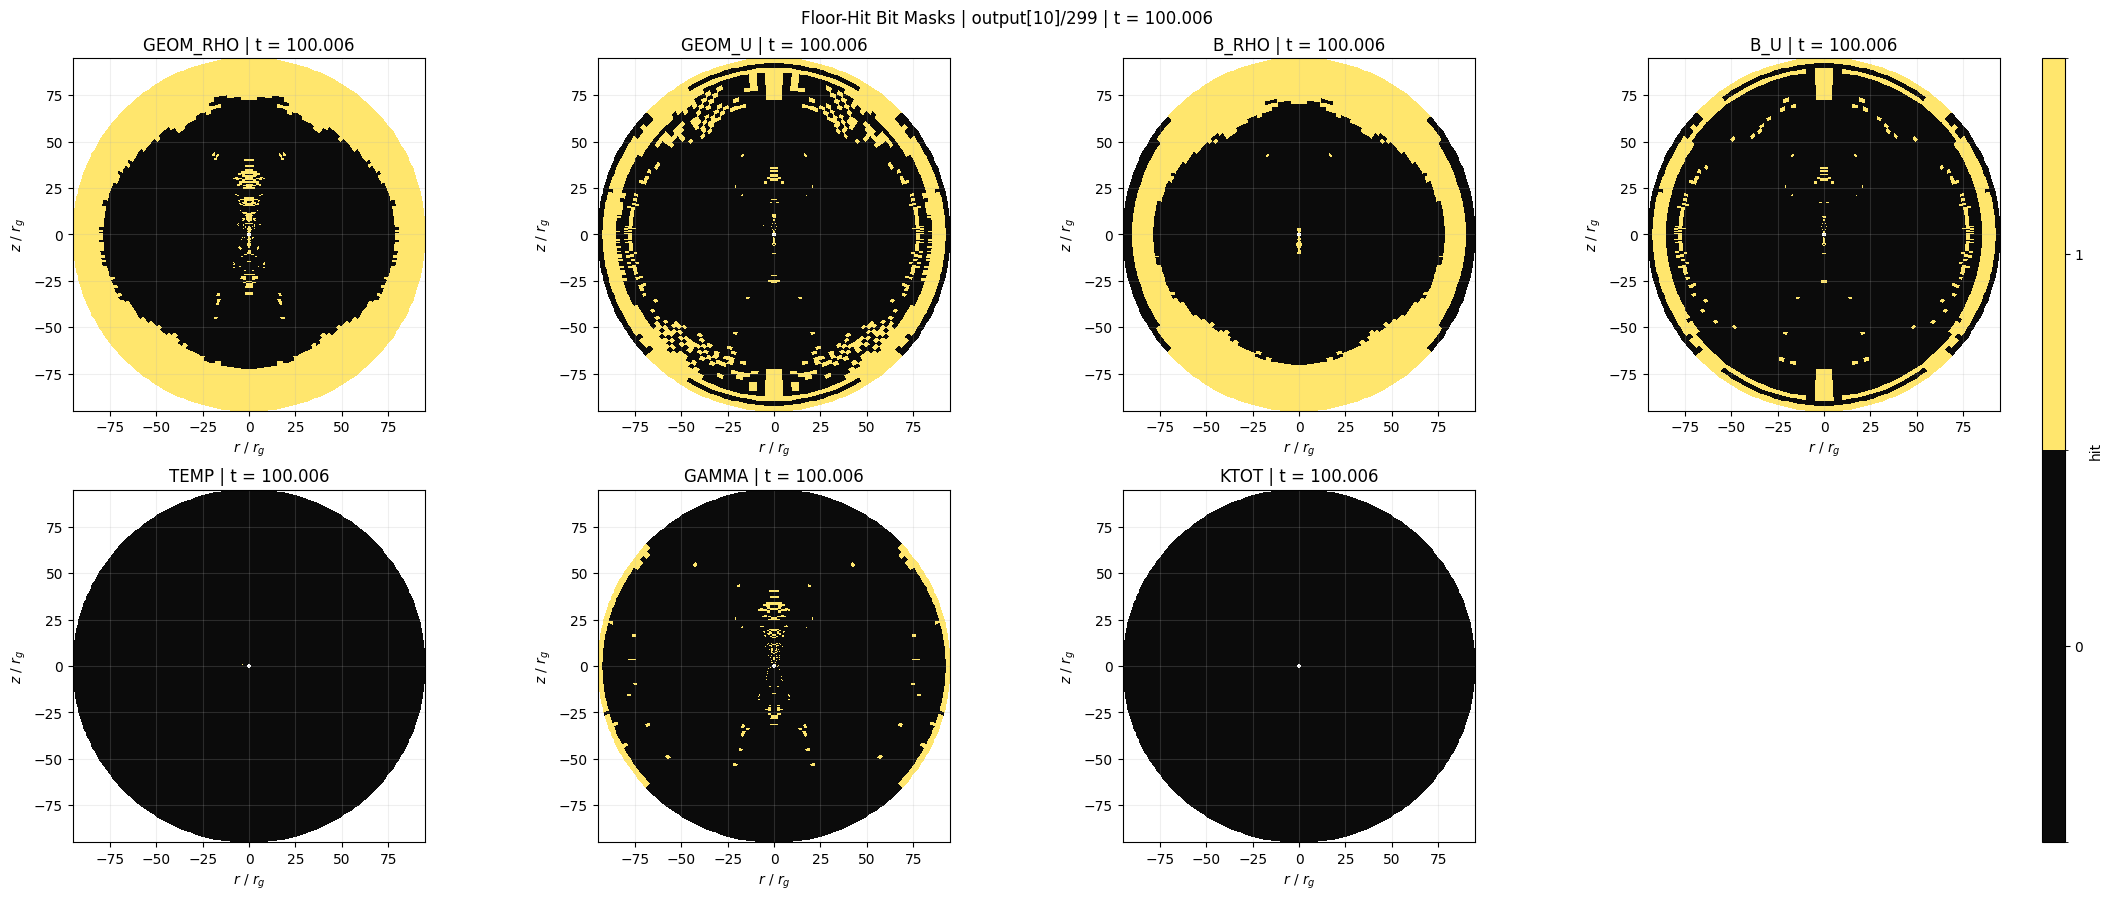

In [18]:
# Plot every floor-hit bit in a single grid for the same frame.
# This is useful for checking whether a stationary structure is density-floor driven,
# magnetization-floor driven, or mostly a ceiling/inversion issue.

bit_order = ["GEOM_RHO", "GEOM_U", "B_RHO", "B_U", "TEMP", "GAMMA", "KTOT"]

dump_time = _read_dump_time(dump_path)
title_suffix = f" | t = {dump_time:.3f}" if dump_time is not None else ""

binary_cmap = plt.matplotlib.colors.ListedColormap(["#0b0b0b", "#ffe66d"])
binary_norm = plt.matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5], binary_cmap.N)

ncols = 4
nrows = 2
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(plot_figsize[0] * ncols / 2.0, plot_figsize[1] * nrows / 1.8),
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

last_im = None
for i, name in enumerate(bit_order):
    ax = axes[i]
    im = ax.pcolormesh(Xplot, Yplot, masks[name].astype(int), shading="auto", cmap=binary_cmap, norm=binary_norm)
    if Xplot_mirror is not None:
        ax.pcolormesh(Xplot_mirror, Yplot_mirror, masks[name].astype(int), shading="auto", cmap=binary_cmap, norm=binary_norm)
    ax.set_title(f"{name}{title_suffix}")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_box_aspect(1)
    _apply_view_limits(ax, r_view, z_view)
    ax.grid(alpha=0.2)
    last_im = im

# Hide any unused axes when bit count does not fill the grid.
for j in range(len(bit_order), len(axes)):
    axes[j].set_visible(False)

if last_im is not None:
    fig.colorbar(last_im, ax=axes[:len(bit_order)], ticks=[0, 1], label="hit", **cbar_kwargs)

fig.suptitle(f"Floor-Hit Bit Masks | output[{resolved_index}]/{n_outputs - 1}{title_suffix}")
plt.show()

In [19]:
# Make an MP4 movie of the 4x2 floor-hit bit-mask grid across outputs.
# Requires ffmpeg available to Matplotlib.

run_meta_resolved_local = globals().get("run_meta_resolved", {"display": "run"})
movie_output = f"floor_hit_bitmask_grid_{run_meta_resolved_local['display'].replace(' ', '_').replace(',', '')}.mp4"
movie_start_index = None   # e.g., 0
movie_stop_index = None    # e.g., 120
movie_step = 1
movie_fps = 8
movie_dpi = 120
movie_overwrite = True
movie_verbose = True
movie_output_index_label = True

plot_figsize_local = globals().get("plot_figsize", (11, 8))
r_limits_local = globals().get("r_limits", None)
z_limits_local = globals().get("z_limits", None)
plot_in_physical_rz_local = bool(globals().get("plot_in_physical_rz", True))
cbar_kwargs_local = globals().get("cbar_kwargs", dict(fraction=0.04, pad=0.02, shrink=1.0, aspect=35))

if "_apply_view_limits" in globals():
    _apply_view_limits_local = _apply_view_limits
else:
    def _apply_view_limits_local(ax, rlim=None, zlim=None):
        if rlim is not None:
            ax.set_xlim(float(rlim[0]), float(rlim[1]))
        if zlim is not None:
            ax.set_ylim(float(zlim[0]), float(zlim[1]))

if not writers.is_available("ffmpeg"):
    raise RuntimeError("ffmpeg is not available to Matplotlib, so MP4 export cannot run.")

bit_order = ["GEOM_RHO", "GEOM_U", "B_RHO", "B_U", "TEMP", "GAMMA", "KTOT"]
mask_defs = {
    "GEOM_RHO": 32,
    "GEOM_U": 64,
    "B_RHO": 128,
    "B_U": 256,
    "TEMP": 512,
    "GAMMA": 1024,
    "KTOT": 2048,
}

binary_cmap = plt.matplotlib.colors.ListedColormap(["#0b0b0b", "#ffe66d"])
binary_norm = plt.matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5], binary_cmap.N)

selected_dumps, selected_indices, all_dumps = _resolve_dump_sequence(
    dump_file=globals().get("dump_file", None),
    available_dumps=globals().get("dump_files", None),
    start_index=movie_start_index,
    stop_index=movie_stop_index,
    step=movie_step,
)

movie_path = Path(movie_output)
if not movie_path.is_absolute():
    movie_path = selected_dumps[0].parent / movie_path
movie_path.parent.mkdir(parents=True, exist_ok=True)

if movie_path.exists() and not movie_overwrite:
    raise FileExistsError(f"Movie already exists: {movie_path}. Set movie_overwrite=True to replace it.")

par_files = sorted(selected_dumps[0].parent.glob("*.par"))
par_cfg = _read_par_file(par_files[0]) if par_files else {}

ncols = 4
nrows = 2
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(plot_figsize_local[0] * ncols / 2.0, plot_figsize_local[1] * nrows / 1.8),
    constrained_layout=False,
)
axes = np.atleast_1d(axes).ravel()

writer = FFMpegWriter(
    fps=movie_fps,
    metadata={"artist": "GitHub Copilot", "title": movie_path.name},
)

with writer.saving(fig, str(movie_path), dpi=movie_dpi):
    for frame_i, (frame_dump, resolved_idx) in enumerate(zip(selected_dumps, selected_indices), start=1):
        dump_time = _read_dump_time(frame_dump)

        with h5py.File(frame_dump, "r") as fh:
            x_edges_blk = fh["Locations/x"][:]
            y_edges_blk = fh["Locations/y"][:]
            block_ids = _build_block_grid(x_edges_blk, y_edges_blk)

            fflag_blk = fh["fflag"][:]
            if fflag_blk.ndim == 4:
                fflag_blk = fflag_blk[:, 0, :, :]
            elif fflag_blk.ndim != 3:
                raise ValueError(f"Unexpected fflag shape: {fflag_blk.shape}")

            fflag = _stitch_blocks_2d(fflag_blk, block_ids)
            fflag = np.asarray(fflag, dtype=np.int64)
            masks = {name: (fflag & bit) != 0 for name, bit in mask_defs.items()}

            x_centers_blk = fh["VolumeLocations/x"][:] if "VolumeLocations/x" in fh else 0.5 * (x_edges_blk[:, :-1] + x_edges_blk[:, 1:])
            y_centers_blk = fh["VolumeLocations/y"][:] if "VolumeLocations/y" in fh else 0.5 * (y_edges_blk[:, :-1] + y_edges_blk[:, 1:])
            x_block_ids = block_ids[0, :]
            y_block_ids = block_ids[:, 0]

            x_edges = np.concatenate([x_edges_blk[b][:-1] for b in x_block_ids] + [x_edges_blk[x_block_ids[-1]][-1:]])
            y_edges = np.concatenate([y_edges_blk[b][:-1] for b in y_block_ids] + [y_edges_blk[y_block_ids[-1]][-1:]])

        Xe, Ye = np.meshgrid(x_edges, y_edges)

        if plot_in_physical_rz_local:
            coord_cfg = {
                "transform": str(par_cfg.get("coordinates/transform", "mks")).lower(),
                "hslope": float(par_cfg.get("coordinates/hslope", 0.3)),
                "mks_smooth": float(par_cfg.get("coordinates/mks_smooth", 0.5)),
                "poly_xt": float(par_cfg.get("coordinates/poly_xt", 0.82)),
                "poly_alpha": float(par_cfg.get("coordinates/poly_alpha", 14.0)),
                "startx1": float(
                    par_cfg.get(
                        "coordinates/fmks_zero_point",
                        par_cfg.get("parthenon/mesh/x1min", float(x_edges[0])),
                    )
                ),
            }

            X1e, X2e = np.meshgrid(x_edges, y_edges)
            r_edges, th_edges = _native_to_r_theta(X1e, X2e, coord_cfg)
            Xplot = r_edges * np.sin(th_edges)
            Yplot = r_edges * np.cos(th_edges)
            Xplot_mirror = r_edges * np.sin(th_edges + np.pi)
            Yplot_mirror = r_edges * np.cos(th_edges + np.pi) * np.cos(np.pi)

            r_auto = float(np.nanmax(np.abs(Xplot)))
            z_auto = float(np.nanmax(np.abs(Yplot)))
            if not np.isfinite(r_auto) or r_auto <= 0:
                r_auto = 1.0
            if not np.isfinite(z_auto) or z_auto <= 0:
                z_auto = 1.0

            r_view = r_limits_local if r_limits_local is not None else (-r_auto, r_auto)
            z_view = z_limits_local if z_limits_local is not None else (-z_auto, z_auto)
            x_label = r"$r$ / $r_g$"
            y_label = r"$z$ / $r_g$"
        else:
            Xplot, Yplot = Xe, Ye
            Xplot_mirror, Yplot_mirror = None, None
            r_view = r_limits_local
            z_view = z_limits_local
            x_label = "x1 (native)"
            y_label = "x2 (native)"

        fig.clear()
        axes = fig.subplots(nrows, ncols).ravel()

        last_im = None
        for i, name in enumerate(bit_order):
            ax = axes[i]
            im = ax.pcolormesh(Xplot, Yplot, masks[name].astype(int), shading="auto", cmap=binary_cmap, norm=binary_norm)
            if Xplot_mirror is not None:
                ax.pcolormesh(Xplot_mirror, Yplot_mirror, masks[name].astype(int), shading="auto", cmap=binary_cmap, norm=binary_norm)
            ax.set_title(name)
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)
            ax.set_box_aspect(1)
            _apply_view_limits_local(ax, r_view, z_view)
            ax.grid(alpha=0.2)
            last_im = im

        for j in range(len(bit_order), len(axes)):
            axes[j].set_visible(False)

        if last_im is not None:
            fig.colorbar(last_im, ax=axes[:len(bit_order)], ticks=[0, 1], label="hit", **cbar_kwargs_local)

        title = "Floor-Hit Bit Masks"
        if movie_output_index_label:
            title += f" | output[{resolved_idx}]/{len(all_dumps) - 1}"
        if dump_time is not None:
            title += f" | t = {dump_time:.3f}"
        fig.suptitle(title)

        writer.grab_frame()

        if movie_verbose:
            print(f"Rendered frame {frame_i}/{len(selected_dumps)}: {frame_dump.name}", end="\r")

plt.close(fig)
if movie_verbose:
    print()
    print(f"Saved movie to {movie_path}")

movie_path

Rendered frame 300/300: torus.out0.00299.phdf
Saved movie to paperModel1_a0.998_t2000_B0ss_20260331_204025/floor_hit_bitmask_grid_PaperModel1_beta=1e4.mp4


PosixPath('paperModel1_a0.998_t2000_B0ss_20260331_204025/floor_hit_bitmask_grid_PaperModel1_beta=1e4.mp4')